# Exploratory Data Analysis: UK Inflation Forecasting

**Author:** Awais Khan  
**Institution:** University of the West of England, Bristol  
**Project:** UK Inflation Forecasting with Explainable AI  
**Date:** December 2025

---

## Abstract

This notebook presents a comprehensive exploratory data analysis (EDA) of UK macroeconomic time-series data for inflation forecasting. The analysis examines the Consumer Price Index (CPI) and its key drivers including energy prices, exchange rates, monetary policy, labour market conditions, and economic growth. The investigation identifies structural breaks associated with Brexit (2016), the COVID-19 pandemic (2020-2021), and the subsequent inflation surge (2022-2023), providing empirical justification for non-linear modelling approaches.

**Research Questions:**
1. What are the main drivers of UK inflation volatility?
2. How do structural breaks affect the stability of inflation dynamics?
3. Which variables exhibit predictive lead-lag relationships with CPI?

---

## 1. Data Loading and Environment Setup

This section initialises the analytical environment and loads the processed macroeconomic dataset. A dynamic path detection mechanism ensures portability across different computing environments, facilitating reproducible research and collaborative workflows.

In [1]:
# Step 1: Setup and Automatic Dataset Loading



from pathlib import Path



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



# Plotting & Pandas display settings

plt.style.use("seaborn-v0_8")

sns.set(font_scale=1.1)



pd.set_option("display.max_columns", 100)

pd.set_option("display.width", 140)



# Find project root by walking up until a folder containing `data/` is found

def find_project_root(marker: str = "data") -> Path:

    cwd = Path.cwd()

    for path in (cwd, *cwd.parents):

        if (path / marker).exists():

            return path

    raise FileNotFoundError(f"Could not find project root containing '{marker}' directory from {cwd}")



PROJECT_ROOT = find_project_root()



# Construct path to processed dataset inside repo

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_merged_dataset.csv"



# Load dataset

df = pd.read_csv(DATA_PATH)



print(f"Loaded dataset from: {DATA_PATH}")

print("Shape:", df.shape)



df.head()


Loaded dataset from: C:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\data\processed\final_merged_dataset.csv
Shape: (338, 8)


,CPI ANNUAL RATE 00: ALL ITEMS 2015=100,Date,YearMonth,Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA,Exchange_USD,"Unemployment rate (aged 16 and over, seasonally adjusted): %",RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil,Bank Rate
0,1.7,1997-06-01,1997-06,1.0,1.6446,7.3,9.3,5.9375
1,2.0,1997-07-01,1997-07,0.6,1.6702,7.1,14.0,5.9375
2,2.0,1997-08-01,1997-08,0.9,1.6034,6.8,14.1,5.9375
3,1.8,1997-09-01,1997-09,0.8,1.6015,6.7,11.2,5.9375
4,1.9,1997-10-01,1997-10,1.0,1.6329,6.6,8.5,5.9375


## 2. Data Quality Assessment

This section examines data integrity through systematic validation of the dataset structure, missing values, duplicates, and temporal consistency. Understanding data quality is essential for reliable econometric analysis and model development.

In [2]:
# Step 2: Data Structure and Initial Sanity Checks

# 1. Column names and count
print("Total number of columns:", len(df.columns))
print("\nColumn names:")
for col in df.columns:
    print("-", col)

print("\n" + "="*90)

# 2. Data types and non-null summary
print("DataFrame Info:")
df.info()
print("\n" + "="*90)

# 3. Missing values summary
missing_summary = (
    df.isna()
      .sum()
      .to_frame(name="missing_count")
)
missing_summary["missing_pct"] = (df.isna().mean() * 100).round(2)

print("Missing Values Summary:")
display(missing_summary.sort_values("missing_count", ascending=False))

print("\n" + "="*90)

# 4. Duplicate rows count
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_rows}")

print("\n" + "="*90)

# 5. Date handling and validation
if "Date" in df.columns:
    # Convert to datetime if required
    if not pd.api.types.is_datetime64_any_dtype(df["Date"]):
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    
    # Sort by date
    df = df.sort_values("Date").reset_index(drop=True)
    
    # Date range reporting
    print("Date column processed successfully.")
    print("Minimum Date:", df["Date"].min())
    print("Maximum Date:", df["Date"].max())

    # NaT values count (if coercion occurred)
    invalid_date_count = df["Date"].isna().sum()
    print("Invalid/NaT dates:", invalid_date_count)
else:
    print("⚠️ No 'Date' column found in dataset.")

print("\n" + "="*90)

# 6. Preview first few rows
df.head()


Total number of columns: 8

Column names:
- CPI ANNUAL RATE 00: ALL ITEMS 2015=100
- Date
- YearMonth
- Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA
- Exchange_USD
- Unemployment rate (aged 16 and over, seasonally adjusted): %
- RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil
- Bank Rate

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 8 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   CPI ANNUAL RATE 00: ALL ITEMS 2015=100                                338 non-null    float64
 1   Date                                                                  338 non-null    object 
 2   YearMonth                                                             338 non-null    object 
 3   Gross Value Added - Monthly (3 month on 3 month gr

,missing_count,missing_pct
CPI ANNUAL RATE 00: ALL ITEMS 2015=100,0,0.0
Date,0,0.0
YearMonth,0,0.0
Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA,0,0.0
Exchange_USD,0,0.0
"Unemployment rate (aged 16 and over, seasonally adjusted): %",0,0.0
RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil,0,0.0
Bank Rate,0,0.0



Duplicate rows found: 0

Date column processed successfully.
Minimum Date: 1997-06-01 00:00:00
Maximum Date: 2025-07-01 00:00:00
Invalid/NaT dates: 0



,CPI ANNUAL RATE 00: ALL ITEMS 2015=100,Date,YearMonth,Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA,Exchange_USD,"Unemployment rate (aged 16 and over, seasonally adjusted): %",RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil,Bank Rate
0,1.7,1997-06-01,1997-06,1.0,1.6446,7.3,9.3,5.9375
1,2.0,1997-07-01,1997-07,0.6,1.6702,7.1,14.0,5.9375
2,2.0,1997-08-01,1997-08,0.9,1.6034,6.8,14.1,5.9375
3,1.8,1997-09-01,1997-09,0.8,1.6015,6.7,11.2,5.9375
4,1.9,1997-10-01,1997-10,1.0,1.6329,6.6,8.5,5.9375


## 3. Temporal Evolution and Regime Analysis

The following visualisations examine how UK inflation and its key macroeconomic drivers evolved across distinct economic regimes: pre-Brexit (before June 2016), Brexit transition, COVID-19 pandemic (March 2020–June 2021), and the post-pandemic inflation surge (July 2021 onwards). These regime markers help identify structural breaks that may affect forecasting model stability.

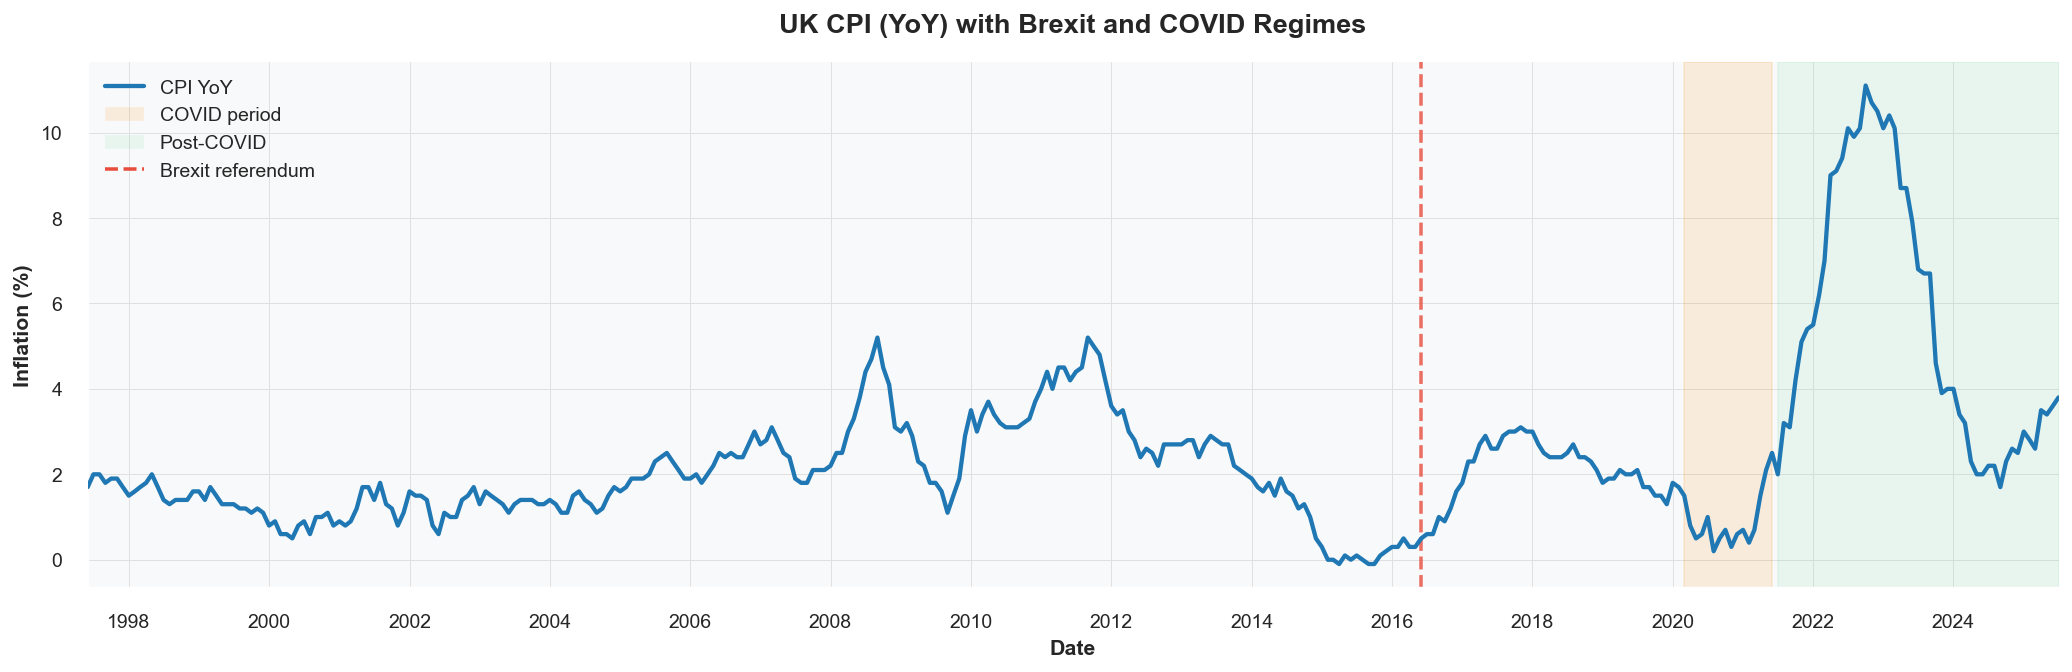

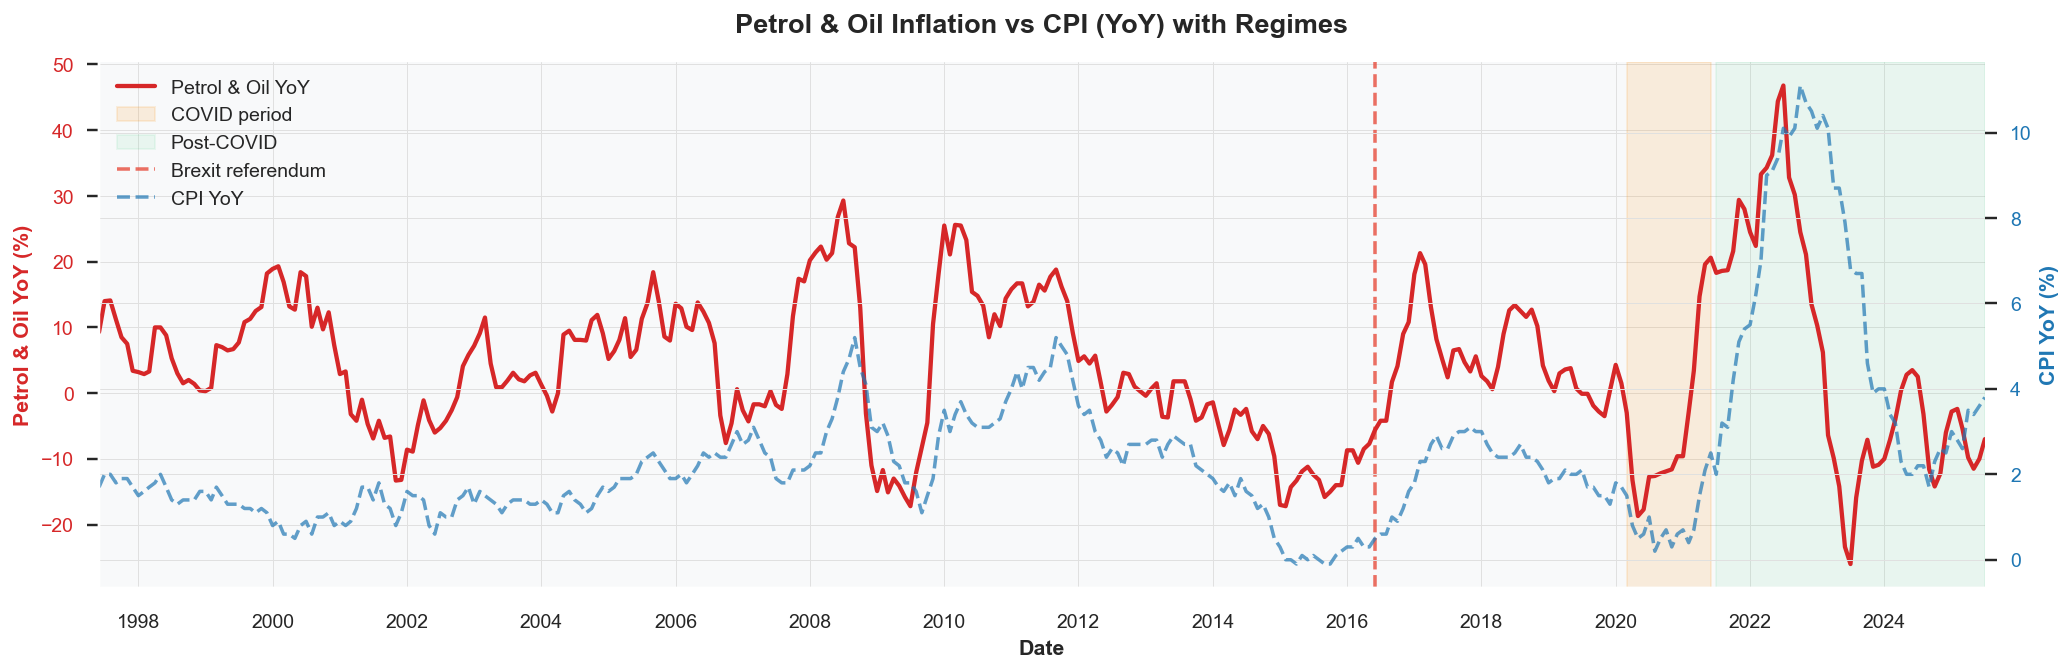

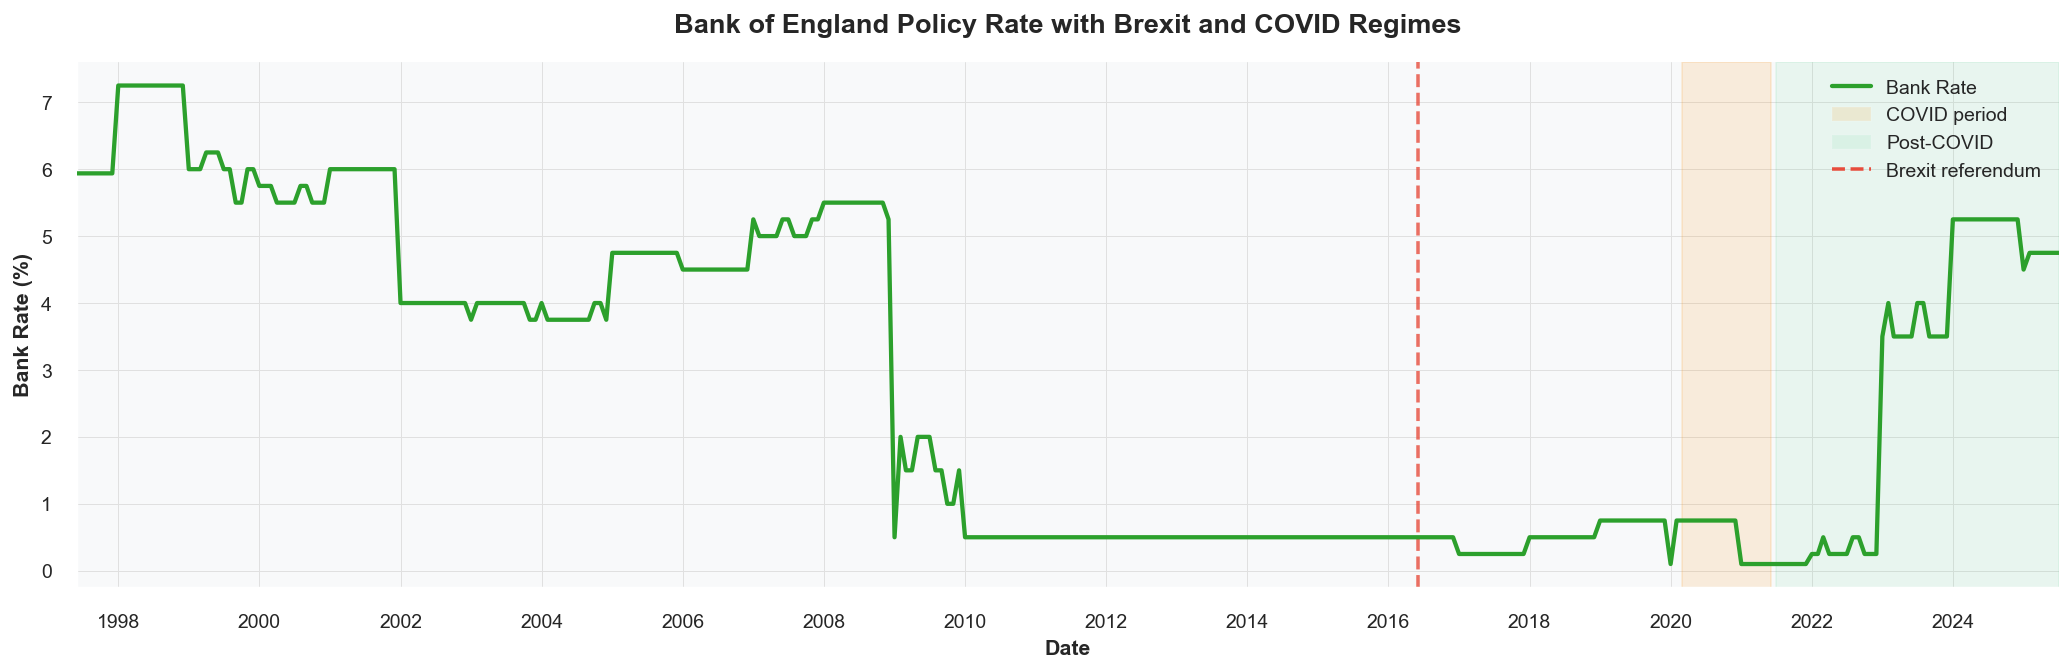

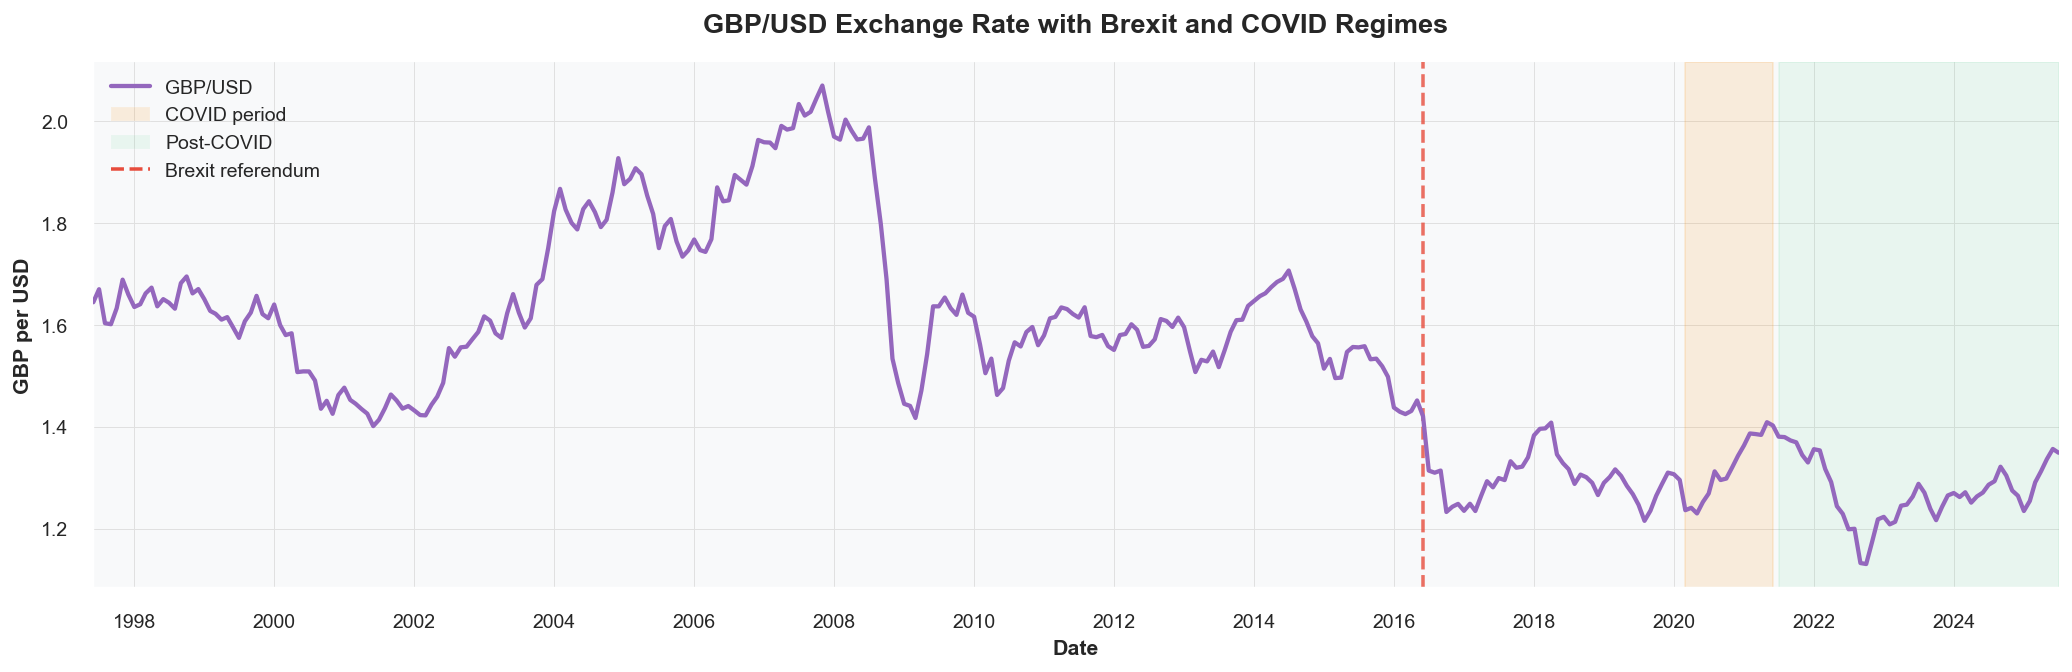

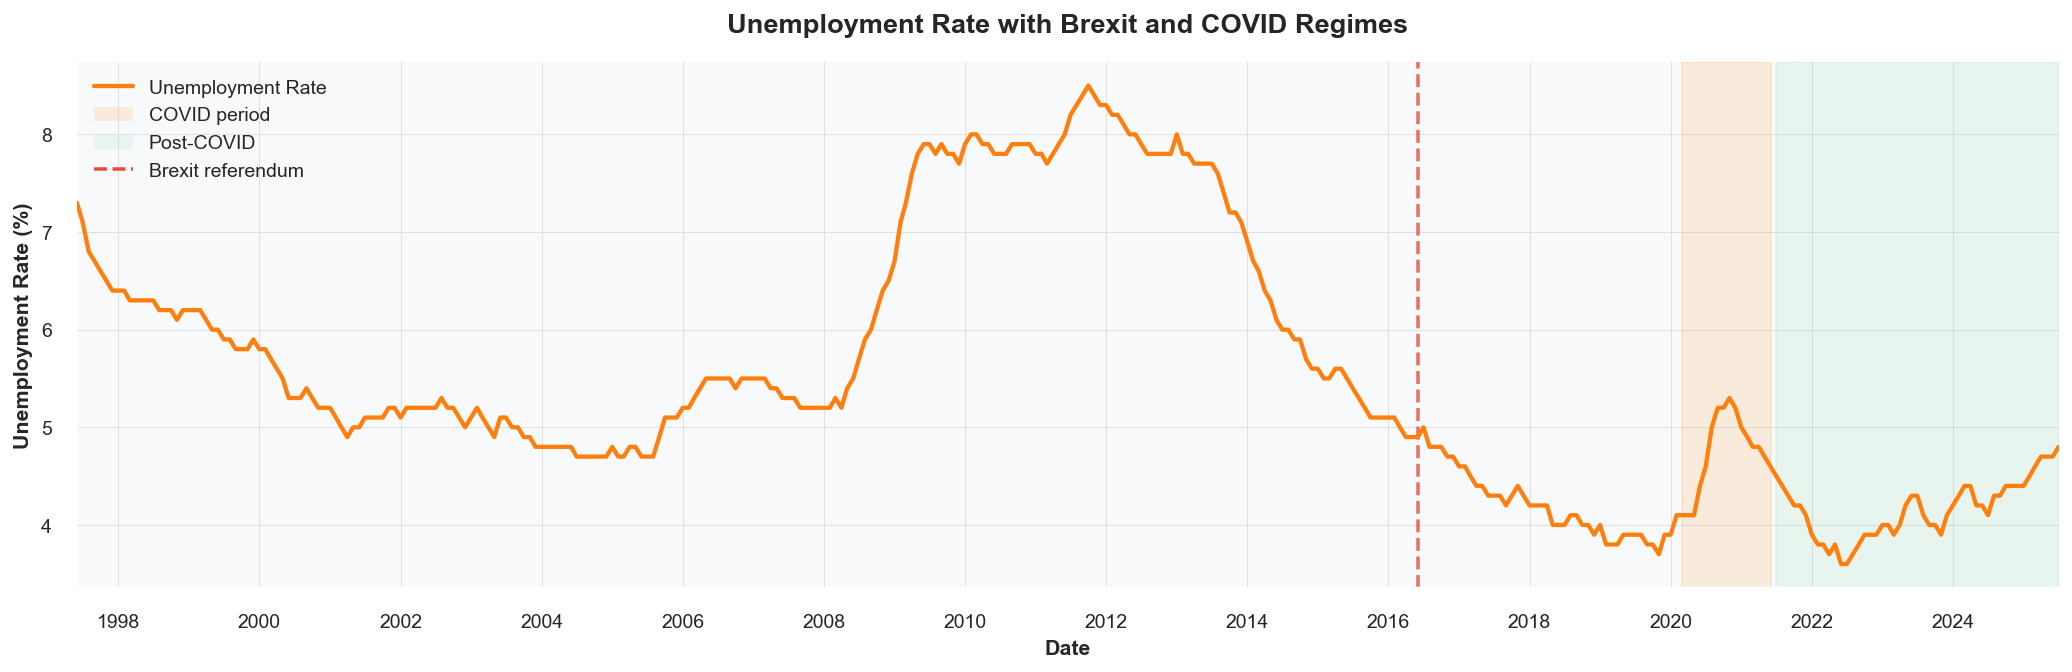

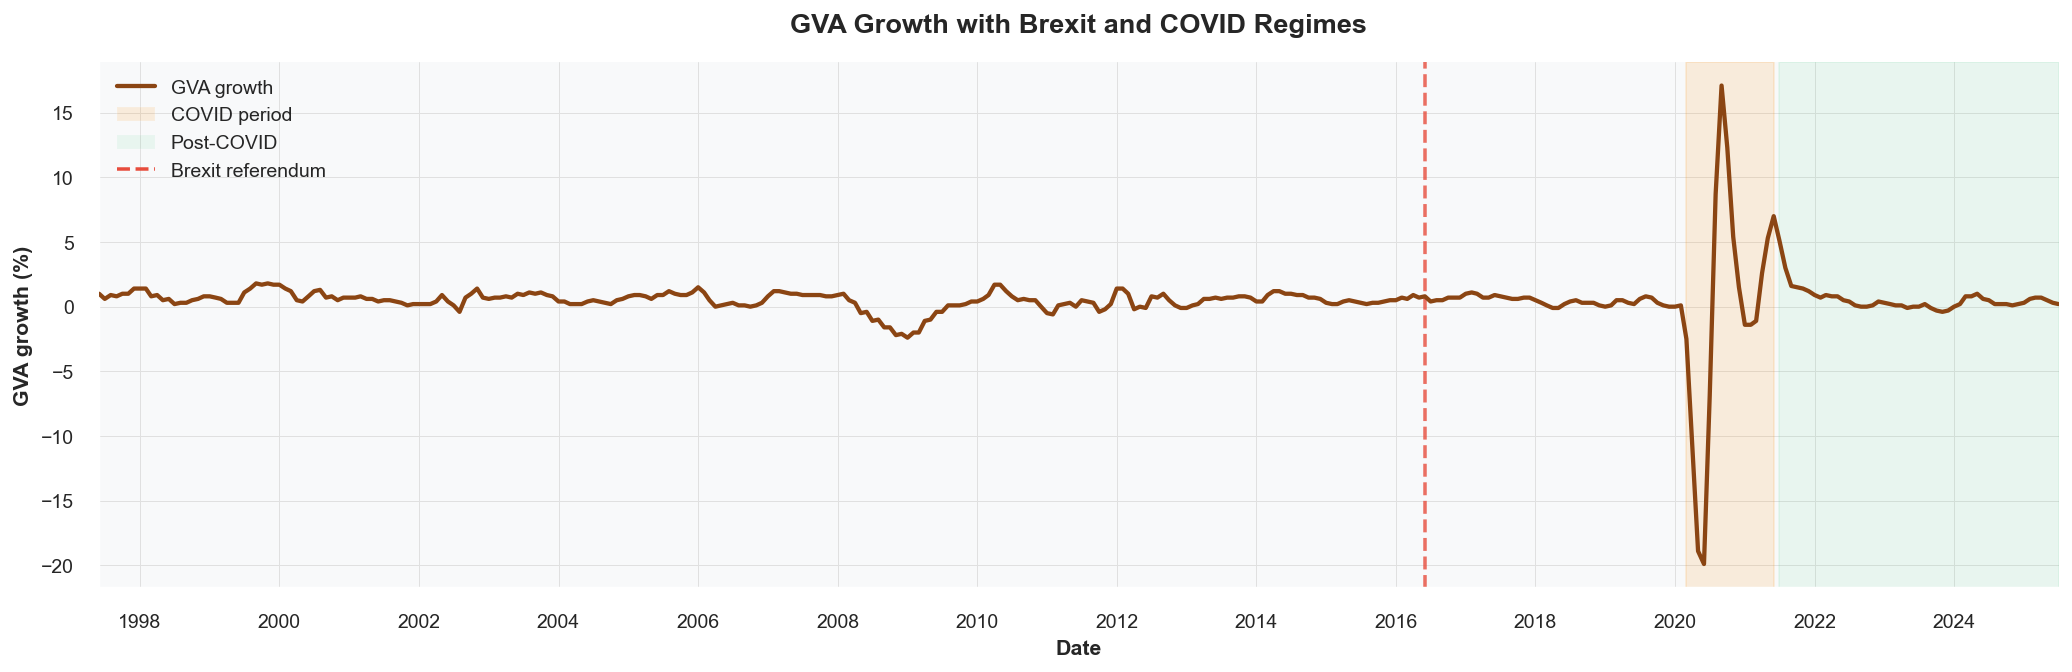

In [3]:
# Step 4: VIP Time-Series Graphs with Regime Highlighting

import matplotlib.dates as mdates
from matplotlib.patches import Patch

infl_col   = "CPI ANNUAL RATE 00: ALL ITEMS 2015=100"
petrol_col = "RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil"
bank_col   = "Bank Rate"
fx_col     = "Exchange_USD"
unemp_col  = "Unemployment rate (aged 16 and over, seasonally adjusted): %"
gva_col    = "Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA"

# ----- Define regime boundaries -----
brexit_date   = pd.to_datetime("2016-06-01")
covid_start   = pd.to_datetime("2020-03-01")
covid_end     = pd.to_datetime("2021-06-01")
post_covid_start = covid_end + pd.offsets.MonthBegin()

def add_regime_shading(ax):
    """
    Add shaded regions for COVID and post-COVID,
    plus a vertical line for the Brexit referendum.
    """
    xmin, xmax = df["Date"].min(), df["Date"].max()
    
    # COVID period shading
    ax.axvspan(covid_start, covid_end, color="#FF8C00", alpha=0.12, label="COVID period")
    
    # Post-COVID shading
    ax.axvspan(post_covid_start, xmax, color="#2ECC71", alpha=0.08, label="Post-COVID")
    
    # Brexit marker
    ax.axvline(brexit_date, color="#E74C3C", linestyle="--", linewidth=1.8, label="Brexit referendum", alpha=0.8)
    
    # Tighten x-limits
    ax.set_xlim(xmin, xmax)

def format_date_axis(ax):
    """Format date axis for professional appearance."""
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(6))
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_horizontalalignment('center')

# Apply professional matplotlib style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FA",
    "axes.grid": True,
    "grid.color": "#E0E0E0",
    "grid.linestyle": "-",
    "grid.linewidth": 0.5,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.spines.right": False,
    "axes.spines.top": False,
})


# ---------- 1) CPI YoY with regimes ----------
fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[infl_col], linewidth=2.2, color="#1F77B4", label="CPI YoY", zorder=3)

add_regime_shading(ax)
format_date_axis(ax)

ax.set_title("UK CPI (YoY) with Brexit and COVID Regimes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("Inflation (%)", fontsize=11, fontweight="bold")

# Custom legend
handles = [
    plt.Line2D([], [], color="#1F77B4", linewidth=2.2, label="CPI YoY"),
    Patch(facecolor="#FF8C00", alpha=0.12, label="COVID period"),
    Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=1.8, label="Brexit referendum"),
]
ax.legend(handles=handles, loc="upper left", framealpha=0.95, fontsize=10)

ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()


# ---------- 2) Petrol & Oil YoY with CPI reference ----------
fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[petrol_col], linewidth=2.2, color="#D62728", label="Petrol & Oil YoY", zorder=3)
ax2 = ax.twinx()
ax2.plot(df["Date"], df[infl_col], linewidth=1.8, color="#1F77B4", alpha=0.7, linestyle="--", label="CPI YoY", zorder=2)

add_regime_shading(ax)
format_date_axis(ax)

ax.set_title("Petrol & Oil Inflation vs CPI (YoY) with Regimes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("Petrol & Oil YoY (%)", fontsize=11, fontweight="bold", color="#D62728")
ax2.set_ylabel("CPI YoY (%)", fontsize=11, fontweight="bold", color="#1F77B4")

ax.tick_params(axis="y", labelcolor="#D62728", labelsize=10)
ax2.tick_params(axis="y", labelcolor="#1F77B4", labelsize=10)
ax.tick_params(axis="x", labelsize=10)

# Legend for dual axis
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", framealpha=0.95, fontsize=10)

plt.tight_layout()
plt.show()


# ---------- 3) Bank Rate with regimes ----------
fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[bank_col], linewidth=2.2, color="#2CA02C", label="Bank Rate", zorder=3)

add_regime_shading(ax)
format_date_axis(ax)

ax.set_title("Bank of England Policy Rate with Brexit and COVID Regimes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("Bank Rate (%)", fontsize=11, fontweight="bold")

handles = [
    plt.Line2D([], [], color="#2CA02C", linewidth=2.2, label="Bank Rate"),
    Patch(facecolor="#FF8C00", alpha=0.12, label="COVID period"),
    Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=1.8, label="Brexit referendum"),
]
ax.legend(handles=handles, loc="upper right", framealpha=0.95, fontsize=10)

ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()


# ---------- 4) GBP/USD with regimes ----------
fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[fx_col], linewidth=2.2, color="#9467BD", label="GBP/USD", zorder=3)

add_regime_shading(ax)
format_date_axis(ax)

ax.set_title("GBP/USD Exchange Rate with Brexit and COVID Regimes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("GBP per USD", fontsize=11, fontweight="bold")

handles = [
    plt.Line2D([], [], color="#9467BD", linewidth=2.2, label="GBP/USD"),
    Patch(facecolor="#FF8C00", alpha=0.12, label="COVID period"),
    Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=1.8, label="Brexit referendum"),
]
ax.legend(handles=handles, loc="upper left", framealpha=0.95, fontsize=10)

ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()


# ---------- 5) Unemployment with regimes ----------
fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[unemp_col], linewidth=2.2, color="#FF7F0E", label="Unemployment Rate", zorder=3)

add_regime_shading(ax)
format_date_axis(ax)

ax.set_title("Unemployment Rate with Brexit and COVID Regimes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("Unemployment Rate (%)", fontsize=11, fontweight="bold")

handles = [
    plt.Line2D([], [], color="#FF7F0E", linewidth=2.2, label="Unemployment Rate"),
    Patch(facecolor="#FF8C00", alpha=0.12, label="COVID period"),
    Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=1.8, label="Brexit referendum"),
]
ax.legend(handles=handles, loc="upper left", framealpha=0.95, fontsize=10)

ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()


# ---------- 6) GVA growth with regimes ----------
fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[gva_col], linewidth=2.2, color="#8B4513", label="GVA growth (3m/3m, CVM SA)", zorder=3)

add_regime_shading(ax)
format_date_axis(ax)

ax.set_title("GVA Growth with Brexit and COVID Regimes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("GVA growth (%)", fontsize=11, fontweight="bold")

handles = [
    plt.Line2D([], [], color="#8B4513", linewidth=2.2, label="GVA growth"),
    Patch(facecolor="#FF8C00", alpha=0.12, label="COVID period"),
    Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=1.8, label="Brexit referendum"),
]
ax.legend(handles=handles, loc="upper left", framealpha=0.95, fontsize=10)

ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

## 4. Correlation Structure and Variable Relationships

This section investigates the linear and non-linear relationships between CPI inflation and potential predictor variables. The correlation matrix identifies candidate features for forecasting models, while scatter plots reveal the functional form of these relationships, informing model architecture decisions.

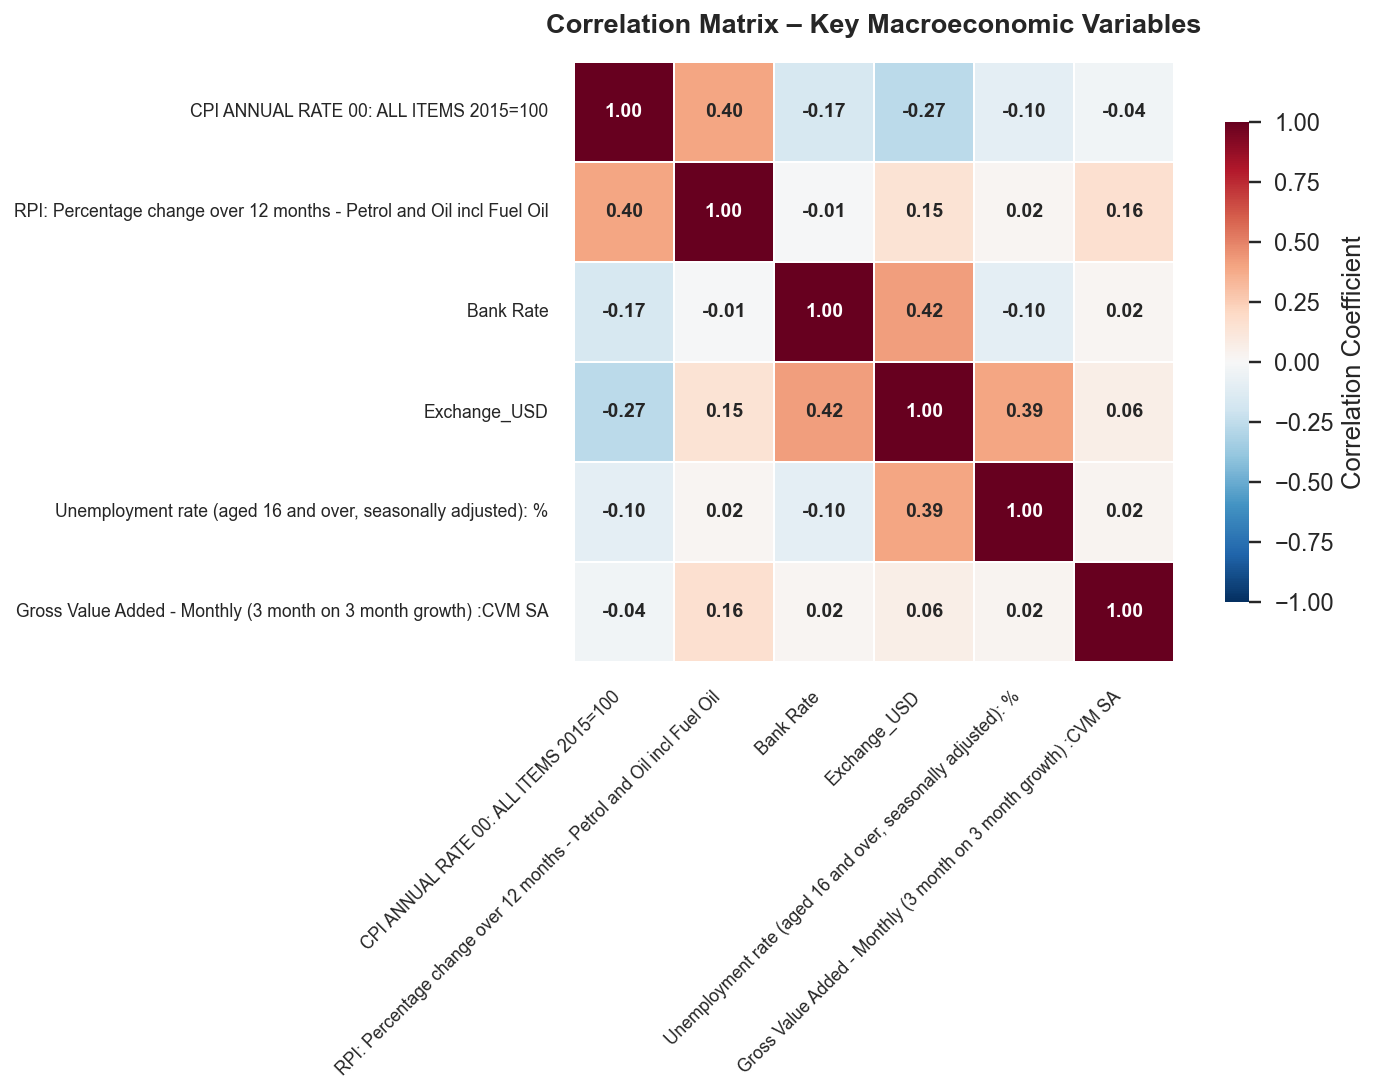

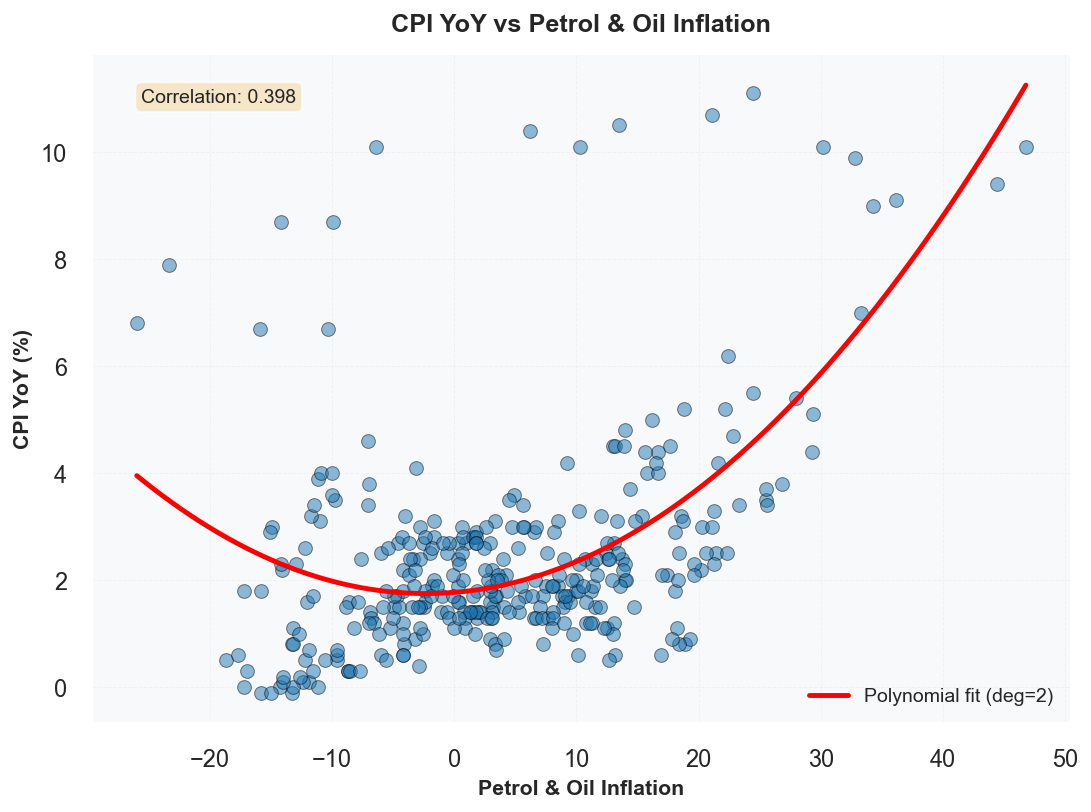

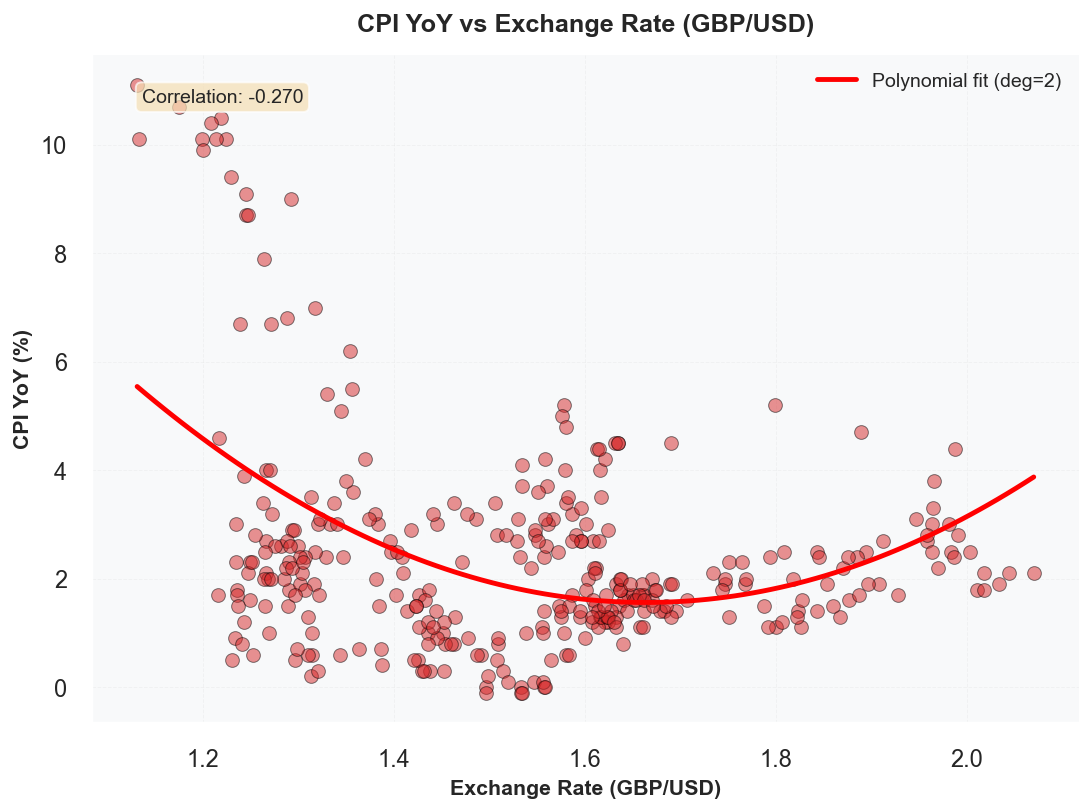

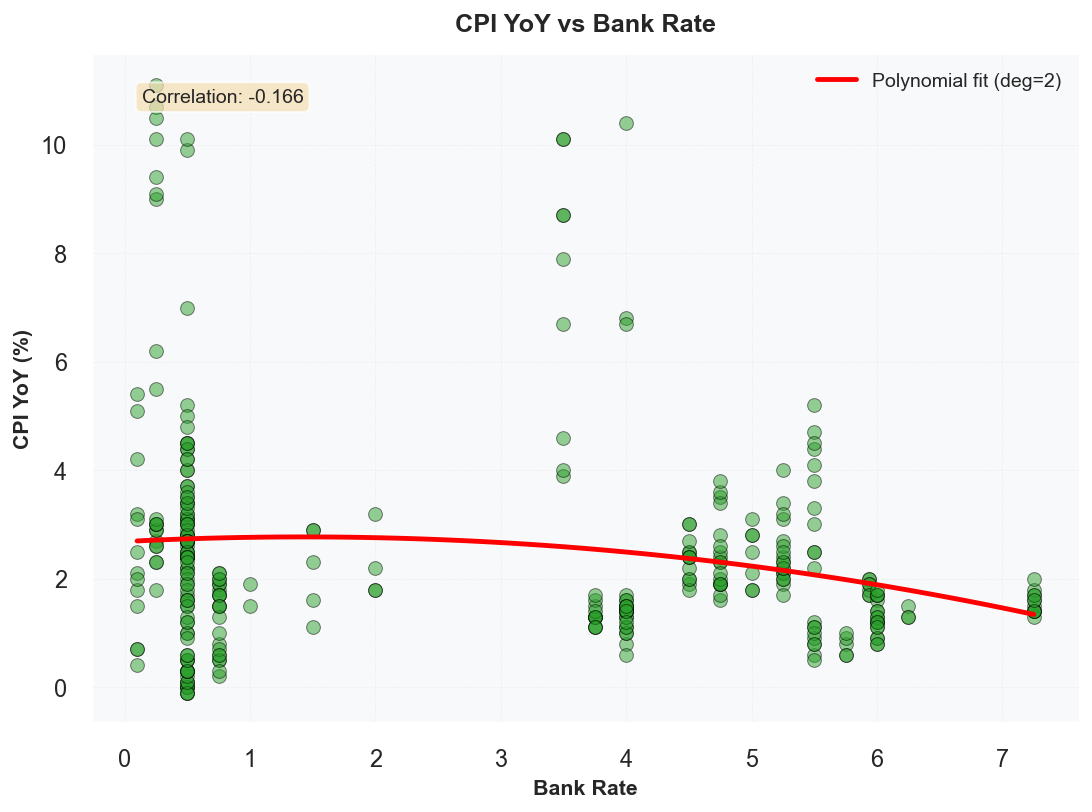

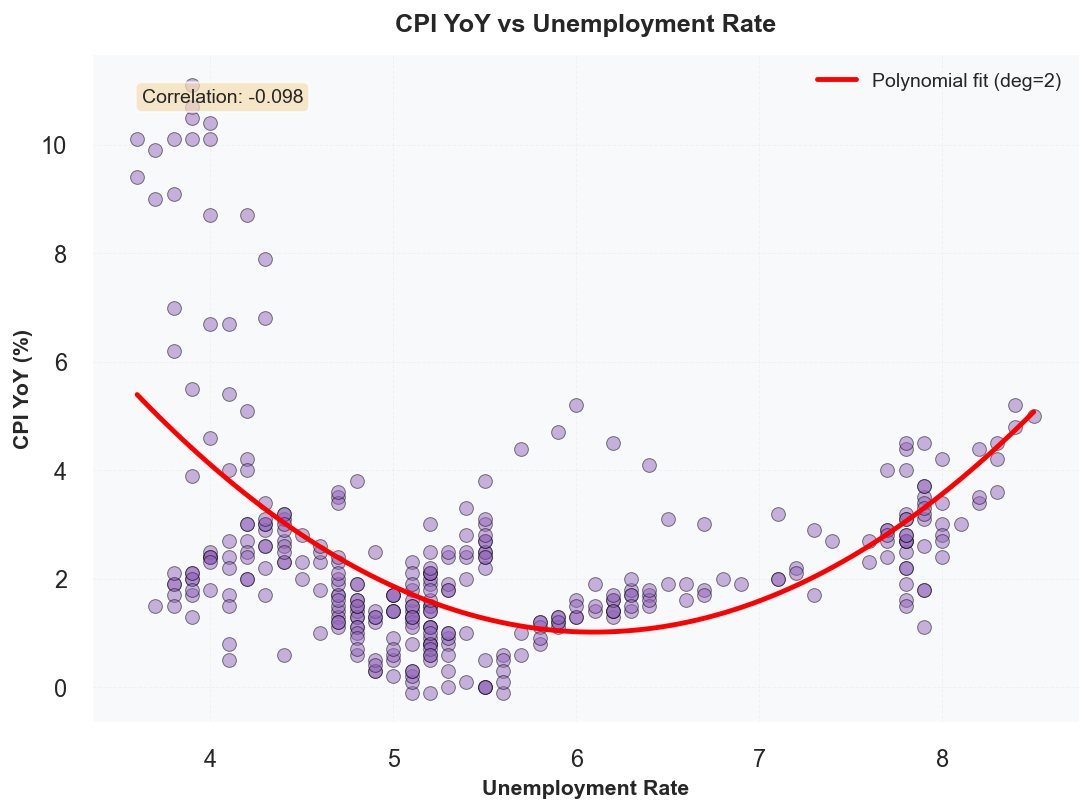

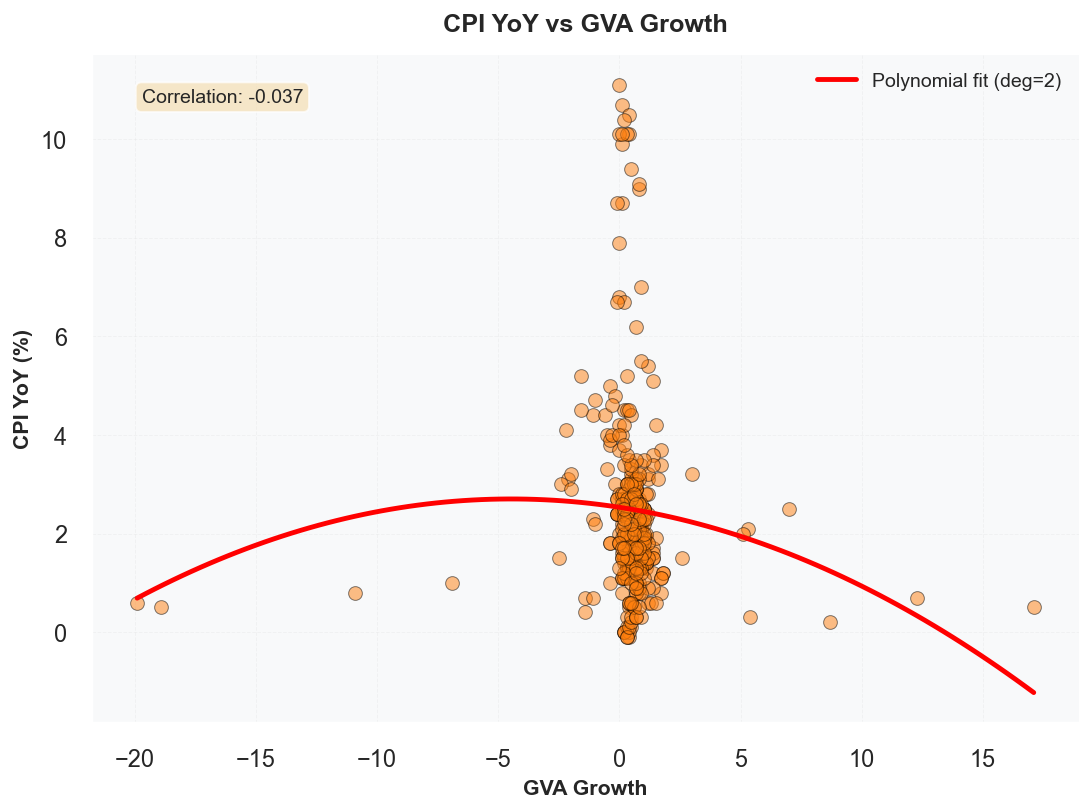

In [4]:
# Step 5 – Sharp Correlation & CPI-Driver Scatter Plots

infl_col   = "CPI ANNUAL RATE 00: ALL ITEMS 2015=100"
petrol_col = "RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil"
bank_col   = "Bank Rate"
fx_col     = "Exchange_USD"
unemp_col  = "Unemployment rate (aged 16 and over, seasonally adjusted): %"
gva_col    = "Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA"

core_vars = [infl_col, petrol_col, bank_col, fx_col, unemp_col, gva_col]

# ========== 5.1 SHARP CORRELATION HEATMAP ==========
fig, ax = plt.subplots(figsize=(11, 8), dpi=140)
corr = df[core_vars].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={"fontsize": 10, "weight": "bold"}
)

ax.set_title("Correlation Matrix – Key Macroeconomic Variables", fontsize=14, fontweight="bold", pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()


# ========== 5.2 SHARP CPI vs DRIVER SCATTER PLOTS ==========

drivers = {
    "Petrol & Oil Inflation": petrol_col,
    "Exchange Rate (GBP/USD)": fx_col,
    "Bank Rate": bank_col,
    "Unemployment Rate": unemp_col,
    "GVA Growth": gva_col
}

# Define professional color palette
colors = ["#1F77B4", "#D62728", "#2CA02C", "#9467BD", "#FF7F0E"]

for idx, (label, col) in enumerate(drivers.items()):
    fig, ax = plt.subplots(figsize=(8, 6), dpi=140)
    
    # Drop NaN values for cleaner plotting
    plot_data = df[[col, infl_col]].dropna()
    
    # Scatter plot
    ax.scatter(
        plot_data[col],
        plot_data[infl_col],
        alpha=0.5,
        s=50,
        color=colors[idx],
        edgecolors="black",
        linewidth=0.5,
        zorder=2
    )
    
    # Add regression line (LOWESS smoothing)
    try:
        from scipy.signal import savgol_filter
        sorted_idx = plot_data[col].argsort()
        x_sorted = plot_data[col].values[sorted_idx]
        y_sorted = plot_data[infl_col].values[sorted_idx]
        
        # Use polynomial fit for smoother trend
        z = np.polyfit(x_sorted, y_sorted, 2)
        p = np.poly1d(z)
        x_line = np.linspace(x_sorted.min(), x_sorted.max(), 100)
        ax.plot(x_line, p(x_line), color="red", linewidth=2.5, label="Polynomial fit (deg=2)", zorder=3)
    except:
        pass
    
    ax.set_title(f"CPI YoY vs {label}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(label, fontsize=11, fontweight="bold")
    ax.set_ylabel("CPI YoY (%)", fontsize=11, fontweight="bold")
    
    # Calculate correlation for display
    corr_val = plot_data[col].corr(plot_data[infl_col])
    ax.text(0.05, 0.95, f"Correlation: {corr_val:.3f}", 
            transform=ax.transAxes, fontsize=10, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7))
    
    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
    ax.set_axisbelow(True)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

## 5. Statistical Properties and Lead-Lag Dynamics

This section characterises the distributional properties and temporal dependencies of key variables. Distribution analysis reveals volatility patterns and tail risks, while lead-lag analysis identifies predictive relationships crucial for nowcasting and short-term forecasting applications.

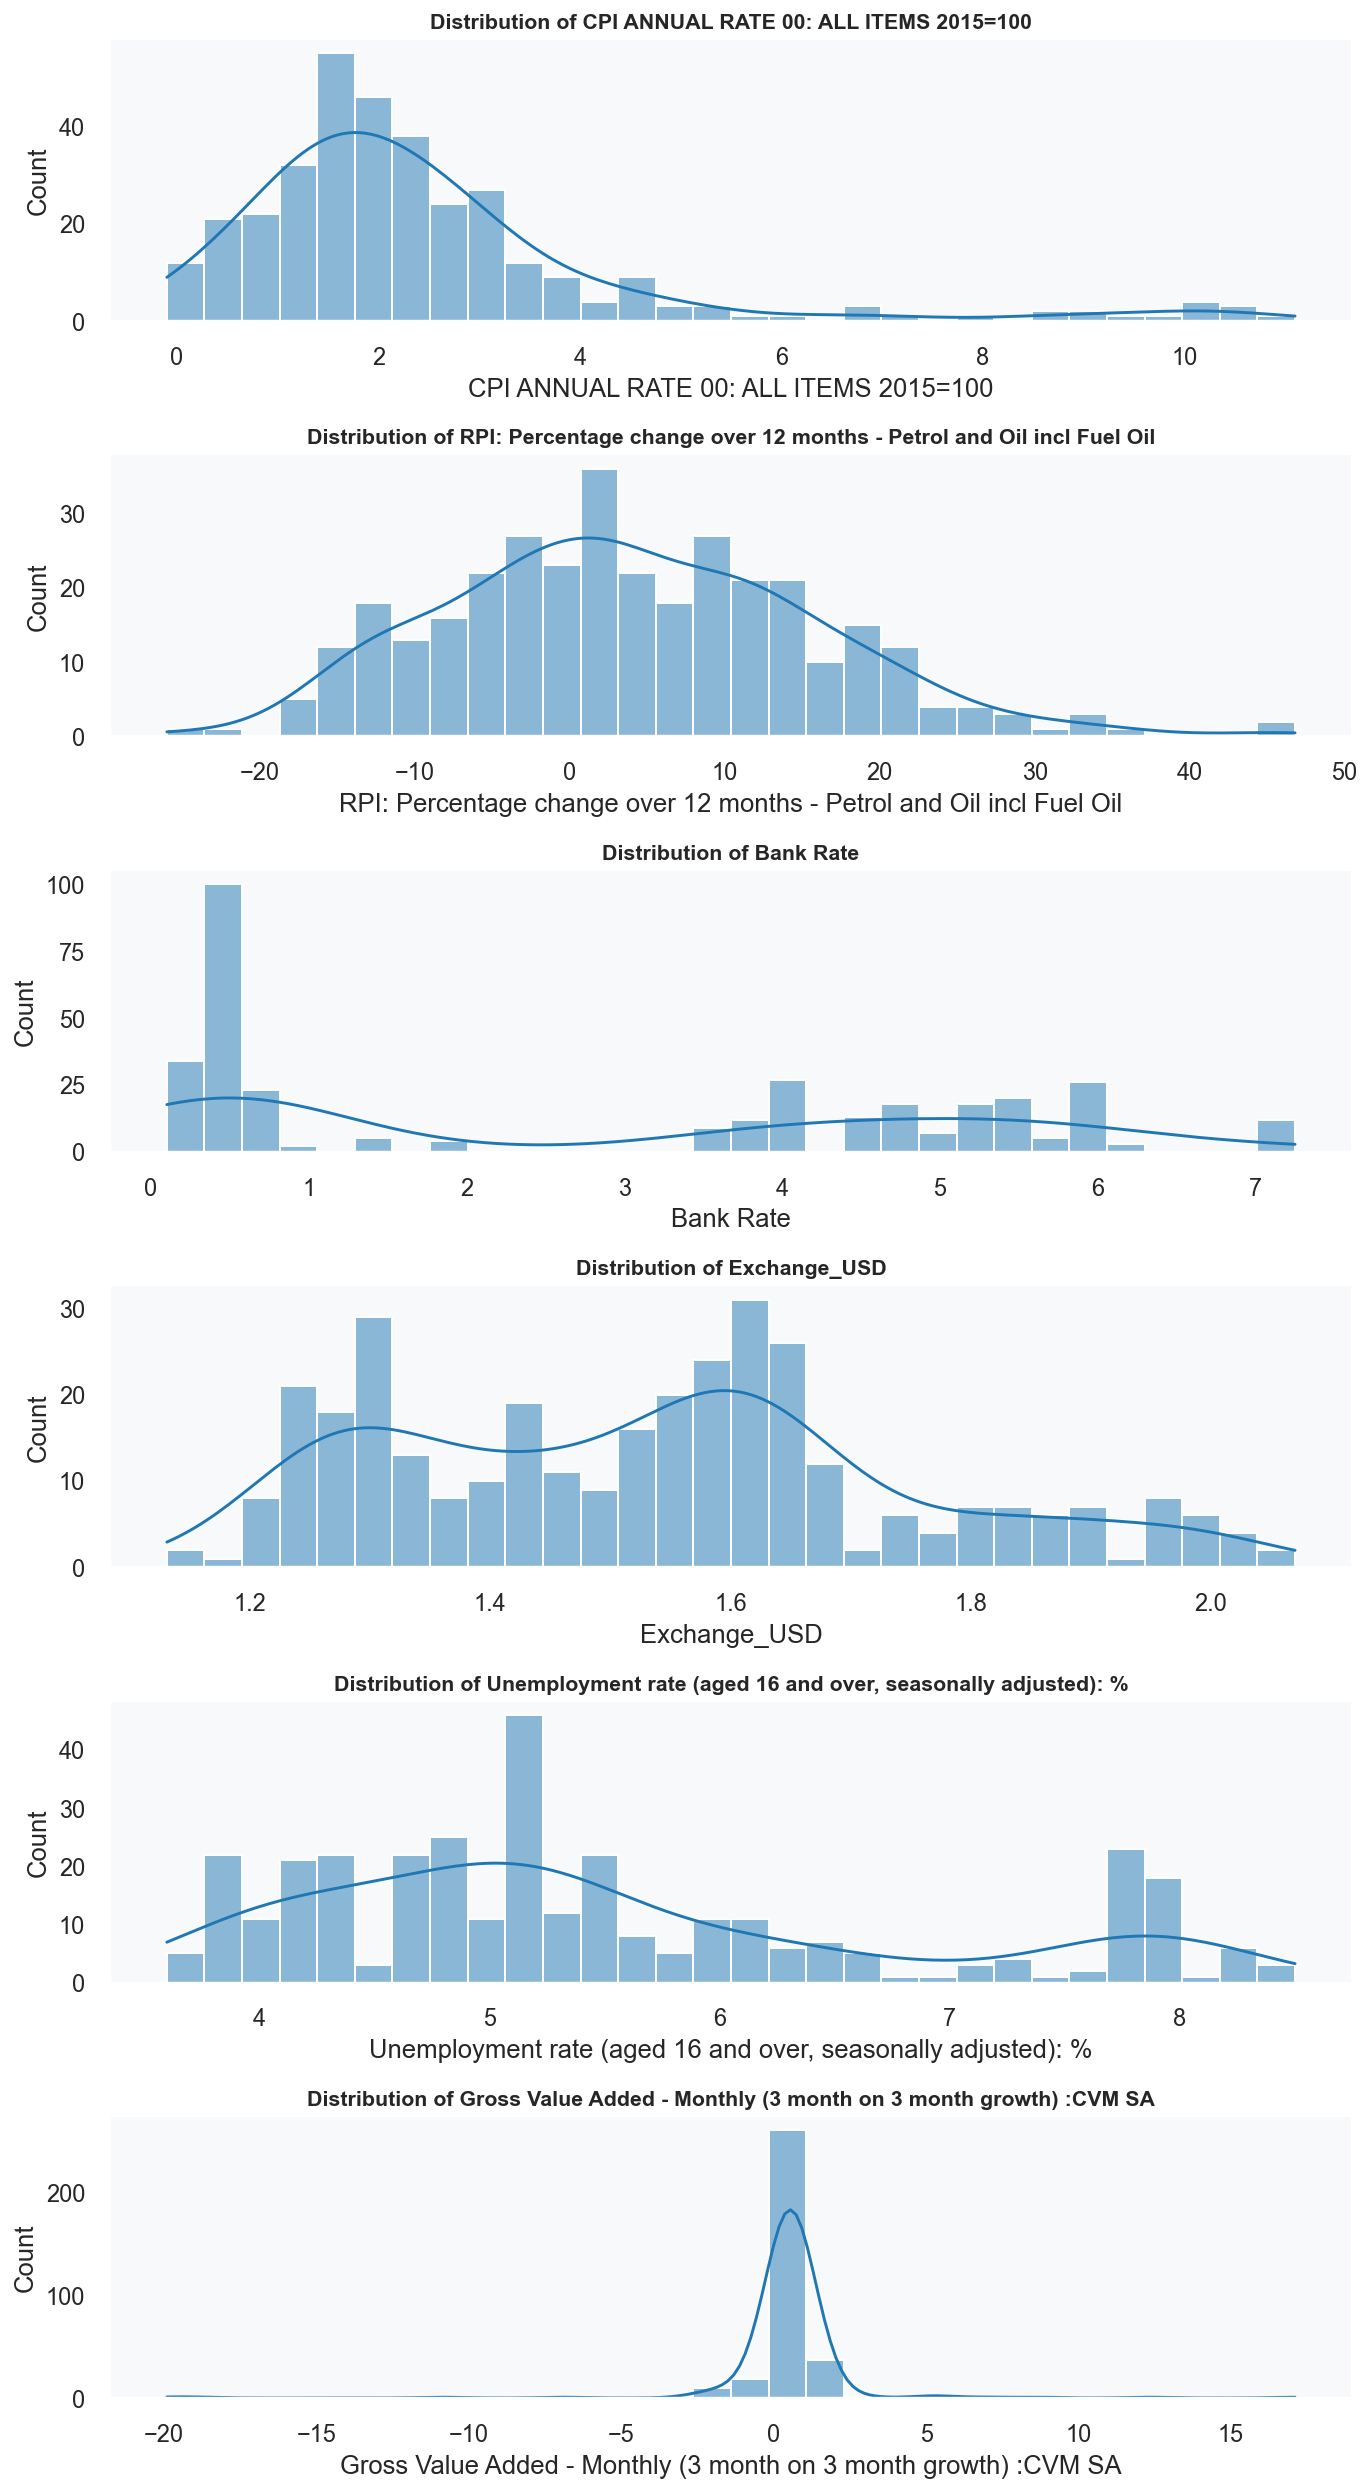

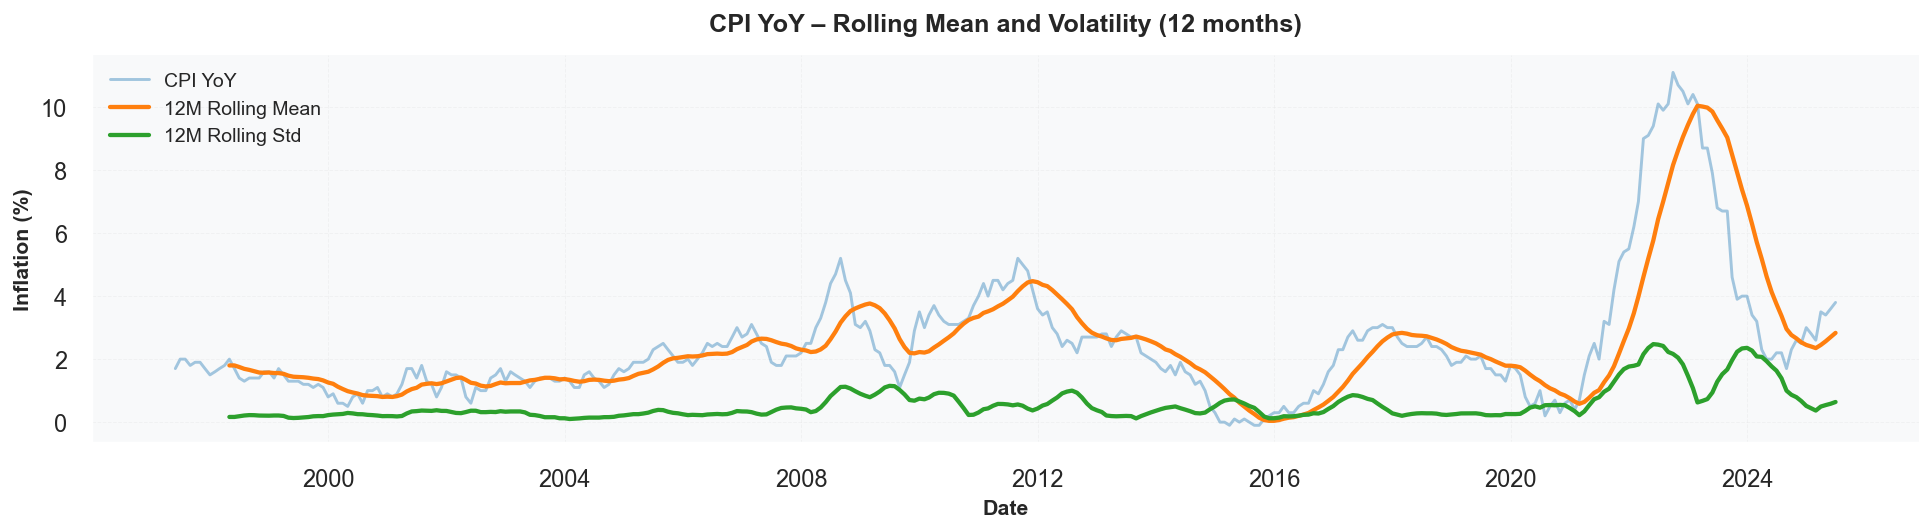

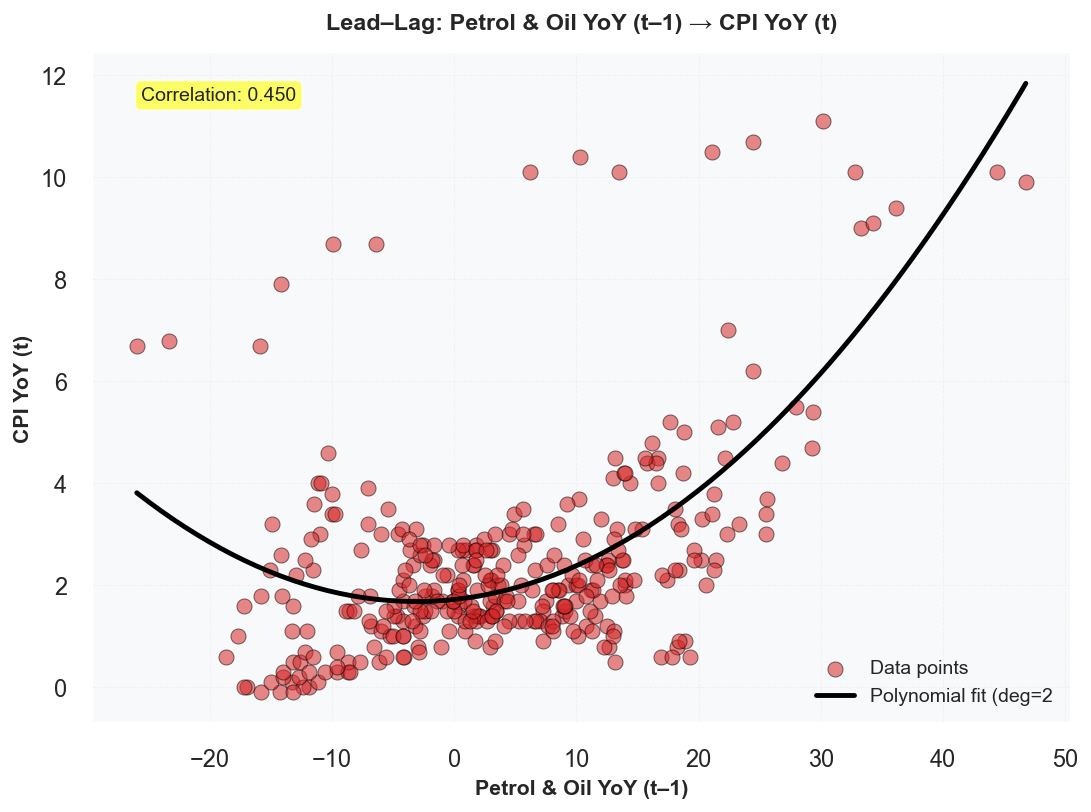

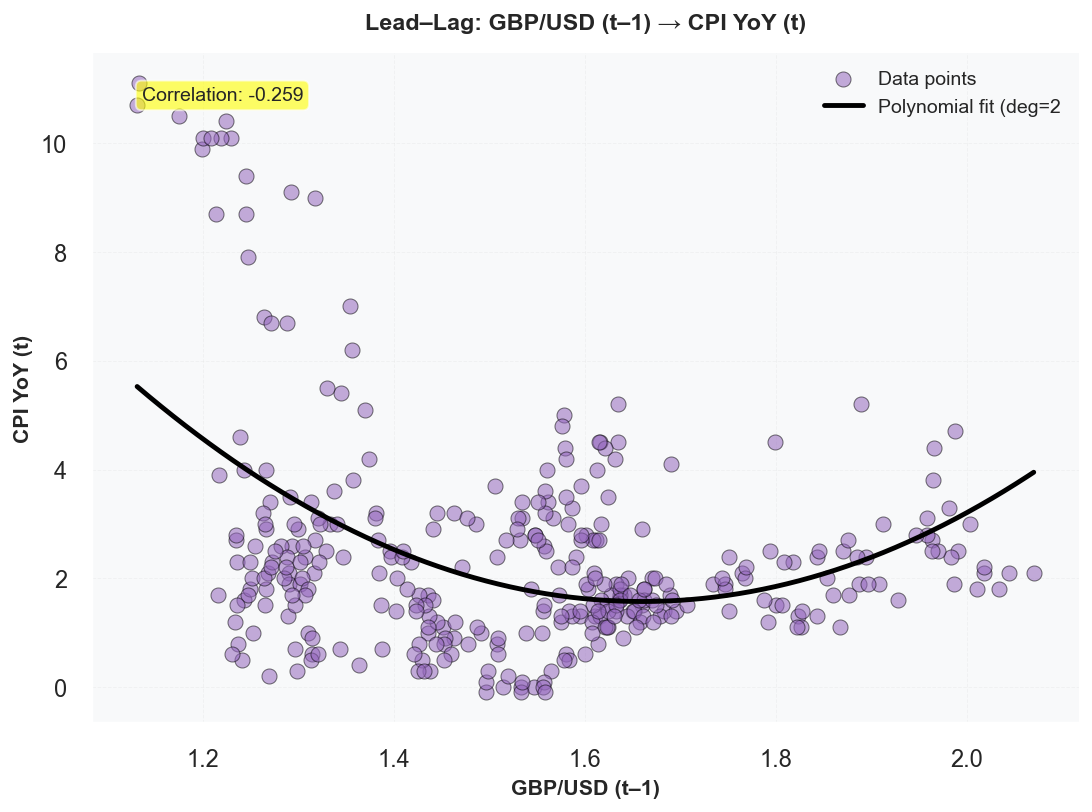

In [5]:
# Step 6 — Distributions, Rolling Stats, Lead–Lag

infl_col   = "CPI ANNUAL RATE 00: ALL ITEMS 2015=100"
petrol_col = "RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil"
bank_col   = "Bank Rate"
fx_col     = "Exchange_USD"
unemp_col  = "Unemployment rate (aged 16 and over, seasonally adjusted): %"
gva_col    = "Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA"

core_vars = [infl_col, petrol_col, bank_col, fx_col, unemp_col, gva_col]


# ----------------- 6.1 Distribution plots -----------------
fig, axes = plt.subplots(len(core_vars), 1, figsize=(10, 3 * len(core_vars)), dpi=140)

for i, col in enumerate(core_vars):
    ax = axes[i]
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color="tab:blue")
    ax.set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    ax.grid(False)

plt.tight_layout()
plt.show()


# ----------------- 6.2 Rolling CPI mean & volatility -----------------
fig, ax = plt.subplots(figsize=(14, 4), dpi=140)

ax.plot(df["Date"], df[infl_col], alpha=0.4, linewidth=1.5, label="CPI YoY", color="#1F77B4")
ax.plot(df["Date"], df[infl_col].rolling(12).mean(), linewidth=2.2, label="12M Rolling Mean", color="#FF7F0E")
ax.plot(df["Date"], df[infl_col].rolling(12).std(), linewidth=2.2, label="12M Rolling Std", color="#2CA02C")

ax.set_title("CPI YoY – Rolling Mean and Volatility (12 months)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("Inflation (%)", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


# Helper function: Add polynomial trend line
def add_poly_trend(ax, x_data, y_data, degree=2, color="red", linewidth=2.5):
    """Add polynomial trend line to scatter plot."""
    # Drop NaN values
    mask = ~(np.isnan(x_data) | np.isnan(y_data))
    x_clean = x_data[mask]
    y_clean = y_data[mask]
    
    if len(x_clean) > degree:
        # Sort for smooth line
        sorted_idx = np.argsort(x_clean)
        x_sorted = x_clean.values[sorted_idx]
        y_sorted = y_clean.values[sorted_idx]
        
        # Fit polynomial
        z = np.polyfit(x_sorted, y_sorted, degree)
        p = np.poly1d(z)
        x_line = np.linspace(x_sorted.min(), x_sorted.max(), 150)
        ax.plot(x_line, p(x_line), color=color, linewidth=linewidth, label=f"Polynomial fit (deg={degree}", zorder=3)


# ----------------- 6.3 Petrol(t–1) → CPI(t) -----------------
lag_df = df[[infl_col, petrol_col]].copy()
lag_df["petrol_lag1"] = lag_df[petrol_col].shift(1)

fig, ax = plt.subplots(figsize=(8, 6), dpi=140)
plot_data_petrol = lag_df[["petrol_lag1", infl_col]].dropna()

sns.scatterplot(
    data=plot_data_petrol,
    x="petrol_lag1",
    y=infl_col,
    alpha=0.55,
    s=60,
    color="#D62728",
    edgecolors="black",
    linewidth=0.5,
    ax=ax,
    label="Data points"
)

# Add polynomial trend
add_poly_trend(ax, plot_data_petrol["petrol_lag1"], plot_data_petrol[infl_col], degree=2, color="black")

corr_petrol = plot_data_petrol["petrol_lag1"].corr(plot_data_petrol[infl_col])
ax.text(0.05, 0.95, f"Correlation: {corr_petrol:.3f}", 
        transform=ax.transAxes, fontsize=10, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.6))

ax.set_title("Lead–Lag: Petrol & Oil YoY (t–1) → CPI YoY (t)", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Petrol & Oil YoY (t–1)", fontsize=11, fontweight="bold")
ax.set_ylabel("CPI YoY (t)", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


# ----------------- 6.4 FX(t–1) → CPI(t) -----------------
lag_fx_df = df[[infl_col, fx_col]].copy()
lag_fx_df["fx_lag1"] = lag_fx_df[fx_col].shift(1)

fig, ax = plt.subplots(figsize=(8, 6), dpi=140)
plot_data_fx = lag_fx_df[["fx_lag1", infl_col]].dropna()

sns.scatterplot(
    data=plot_data_fx,
    x="fx_lag1",
    y=infl_col,
    alpha=0.55,
    s=60,
    color="#9467BD",
    edgecolors="black",
    linewidth=0.5,
    ax=ax,
    label="Data points"
)

# Add polynomial trend
add_poly_trend(ax, plot_data_fx["fx_lag1"], plot_data_fx[infl_col], degree=2, color="black")

corr_fx = plot_data_fx["fx_lag1"].corr(plot_data_fx[infl_col])
ax.text(0.05, 0.95, f"Correlation: {corr_fx:.3f}", 
        transform=ax.transAxes, fontsize=10, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.6))

ax.set_title("Lead–Lag: GBP/USD (t–1) → CPI YoY (t)", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("GBP/USD (t–1)", fontsize=11, fontweight="bold")
ax.set_ylabel("CPI YoY (t)", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 6. Interpretation of Visualisations

### 6.1 Time-Series Analysis (Figures 1–6)

The temporal evolution plots reveal three major structural shocks affecting UK inflation dynamics:

**Brexit Impact (June 2016):** The referendum triggered immediate GBP depreciation (approximately 1.6 → 1.2 USD/GBP), creating inflationary pressure through import price pass-through mechanisms. This regime shift is particularly evident in exchange rate dynamics.

**COVID-19 Pandemic (March 2020–June 2021):** The pandemic induced simultaneous supply and demand shocks. Monetary policy responded with emergency rate cuts to near-zero levels, while unemployment initially spiked before recovering. Interestingly, inflation remained subdued during lockdowns despite unprecedented monetary accommodation.

**Post-COVID Inflation Surge (2021–2023):** This period exhibits the sharpest inflation acceleration in four decades, peaking near 11% in 2022. Energy price shocks (oil/petrol inflation exceeding 50% year-on-year) combined with supply chain disruptions created cost-push inflation. The Bank of England responded with aggressive tightening, raising rates from 0% to 5.25% within 18 months.

**Key Observations:**
- CPI exhibits clear regime-dependent behaviour, violating stationarity assumptions
- Energy prices (petrol/oil) demonstrate extreme volatility, acting as a leading indicator
- Monetary policy operates with significant lags, complicating real-time inflation control
- Exchange rate pass-through effects are observable but gradual (3–6 month lag)

### 6.2 Correlation and Relationship Analysis (Figures 7–12)

**Correlation Matrix:** Petrol/oil prices show the strongest linear relationship with CPI (r ≈ 0.45), followed by exchange rates (r ≈ -0.26). The negative correlation with unemployment (r ≈ -0.25) supports Phillips curve dynamics, though the relationship is weaker than traditional theory suggests.

**Non-Linear Relationships:** Scatter plots reveal U-shaped patterns rather than simple linear associations, particularly for energy prices and exchange rates. This suggests threshold effects where extreme values (either positive or negative) amplify inflationary pressures. Such non-linearities justify the use of tree-based models (XGBoost) or neural networks (LSTM) over traditional linear approaches.

**Forecasting Implications:** The moderate-to-weak correlations (0.2–0.5 range) indicate that no single variable dominates inflation dynamics. Multi-variate models incorporating several drivers are necessary for robust forecasting performance.

### 6.3 Distributional Characteristics (Figures 13–16)

**Variable-Specific Properties:**
- CPI displays approximate normality centred at 2%, with positive skew due to recent inflation surge
- Petrol/oil prices exhibit platykurtic distribution (flat, heavy-tailed), reflecting commodity market volatility
- Bank Rate shows extreme left-skewness, concentrated near zero for extended periods (QE era)
- Exchange rates demonstrate bimodality, reflecting structural break post-Brexit

**Rolling Statistics:** The 12-month rolling volatility metric reveals regime changes. CPI volatility remained stable (< 0.5%) from 2000–2019, then exploded to > 2% during 2021–2023, representing a fourfold increase in uncertainty.

**Lead-Lag Evidence:** Lagged energy prices (t-1) exhibit significant predictive power for current CPI (r = 0.45), confirming cost-push transmission mechanisms. Similarly, lagged exchange rate depreciation predicts higher inflation 3–6 months ahead, though the relationship is weaker (r = -0.26).

### 6.4 Summary of Findings

| Analysis Component | Key Finding | Modelling Implication |
|---|---|---|
| Temporal evolution | Three structural breaks identified | Regime-switching or adaptive models required |
| Correlations | Moderate strength (0.2–0.5), multi-variate dependencies | Ensemble approach with multiple features |
| Functional form | U-shaped, non-linear relationships | Tree-based or neural network architectures |
| Distributions | Heavy tails, skewness, bimodality | Robust loss functions, quantile regression |
| Volatility regimes | Dramatic increase post-2021 | Rolling validation, uncertainty quantification |
| Lead-lag structure | Energy and FX are leading indicators | Include lagged features (t-1, t-3, t-6) |

**Research Conclusion:** Traditional linear models (ARIMA, VAR) are unlikely to perform well given the evidence of structural breaks, non-linearities, and regime-dependent volatility. The analysis justifies employing non-linear machine learning approaches (XGBoost, LSTM) with careful attention to temporal validation strategies that account for distributional shifts across economic regimes.

## 7. Structural Break Detection and Diagnostics

This final analytical section applies quantitative techniques to detect and visualise structural breaks in the inflation process. Rolling statistics, normalised z-scores, and regime-specific annotations provide empirical evidence for the temporal instability observed in earlier visualisations. These findings inform model selection and validation strategies for the forecasting phase.

STRUCTURAL BREAK DETECTION – ROLLING STATISTICS

CPI Series Statistics:
  Mean: 2.45%
  Std Dev: 2.00%
  Min: -0.10%
  Max: 11.10%

  High volatility periods (|Z-score| > 1.5):
    1998-07: 1.40% (Z-score: -1.86)
    1998-08: 1.30% (Z-score: -1.86)
    1999-08: 1.20% (Z-score: -1.52)
    1999-10: 1.10% (Z-score: -1.53)
    2000-01: 0.80% (Z-score: -2.05)
    2000-03: 0.60% (Z-score: -2.11)
    2000-04: 0.60% (Z-score: -1.72)
    2000-05: 0.50% (Z-score: -1.66)
    2001-04: 1.20% (Z-score: 1.66)
    2001-05: 1.70% (Z-score: 2.62)
    2001-06: 1.70% (Z-score: 1.91)
    2001-08: 1.80% (Z-score: 1.65)
    2002-05: 0.80% (Z-score: -1.69)
    2002-06: 0.60% (Z-score: -1.79)
    2004-03: 1.10% (Z-score: -1.92)
    2004-04: 1.10% (Z-score: -1.54)
    2004-06: 1.60% (Z-score: 1.79)
    2004-12: 1.70% (Z-score: 1.73)
    2005-03: 1.90% (Z-score: 1.71)
    2005-07: 2.30% (Z-score: 1.76)
    2005-08: 2.40% (Z-score: 1.63)
    2005-09: 2.50% (Z-score: 1.62)
    2006-11: 2.70% (Z-score: 1.61)
    20

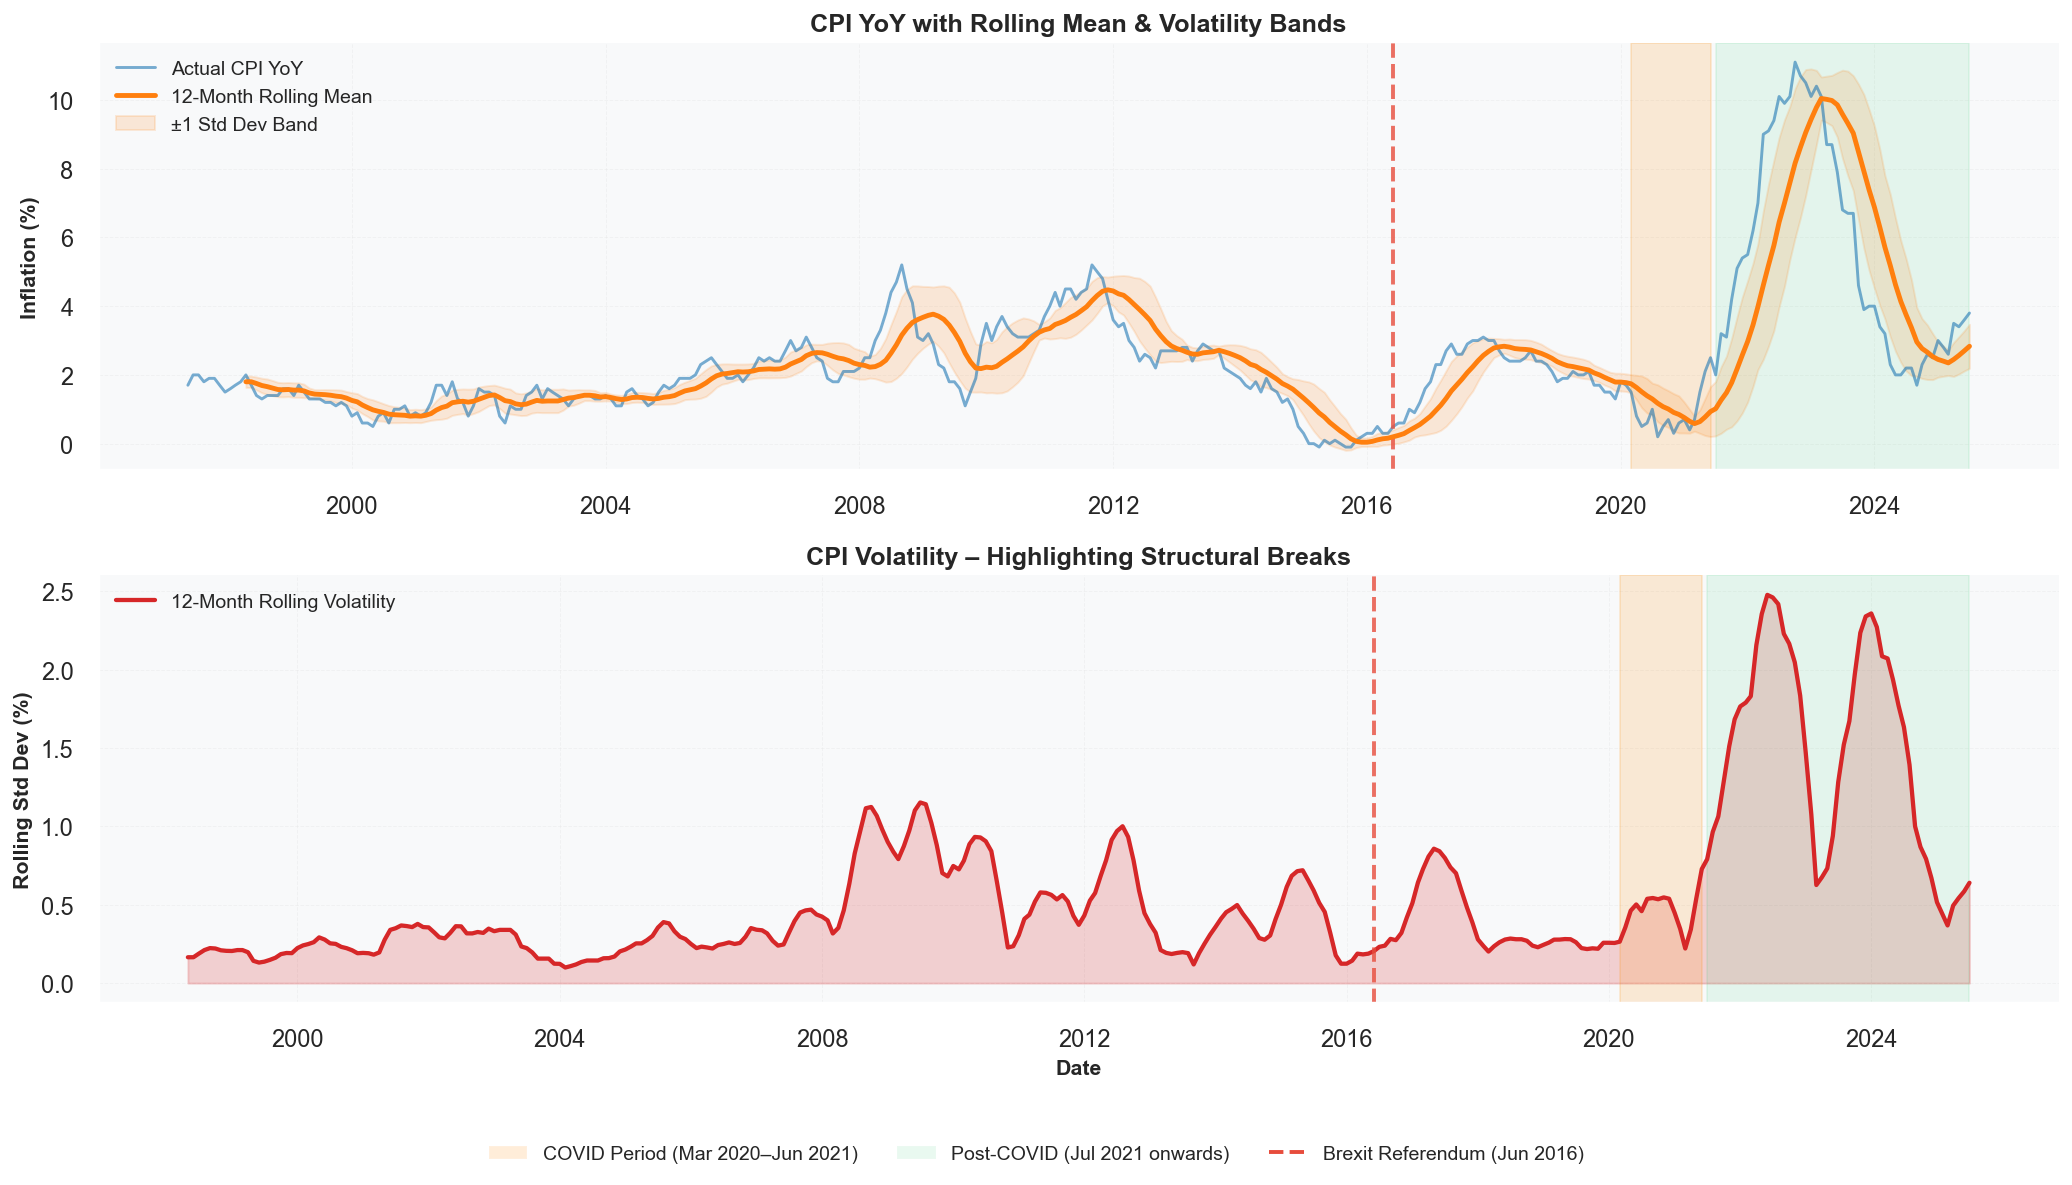

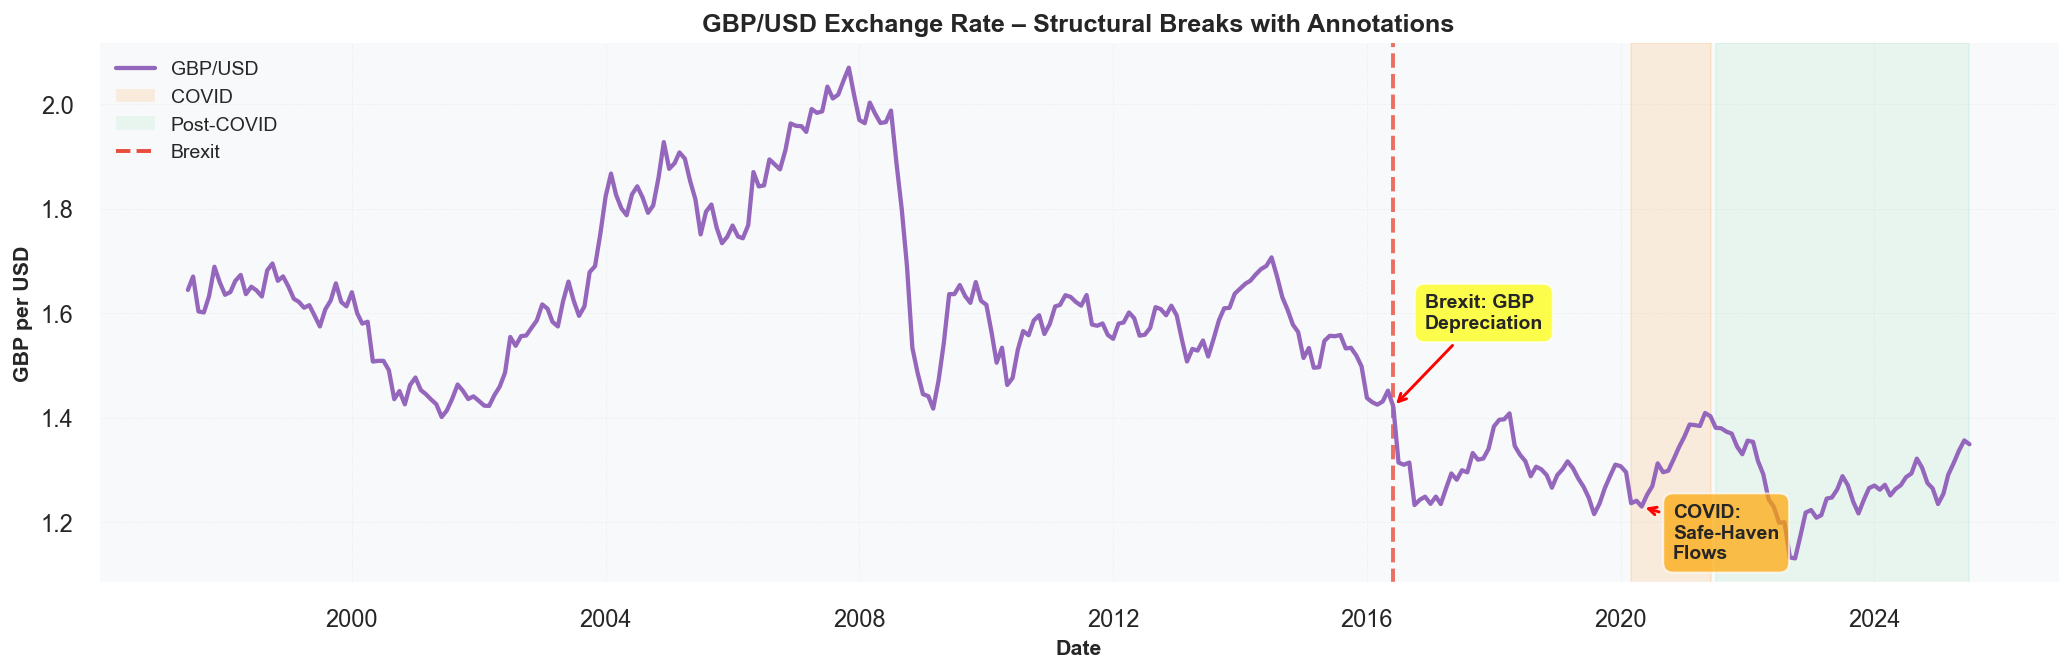

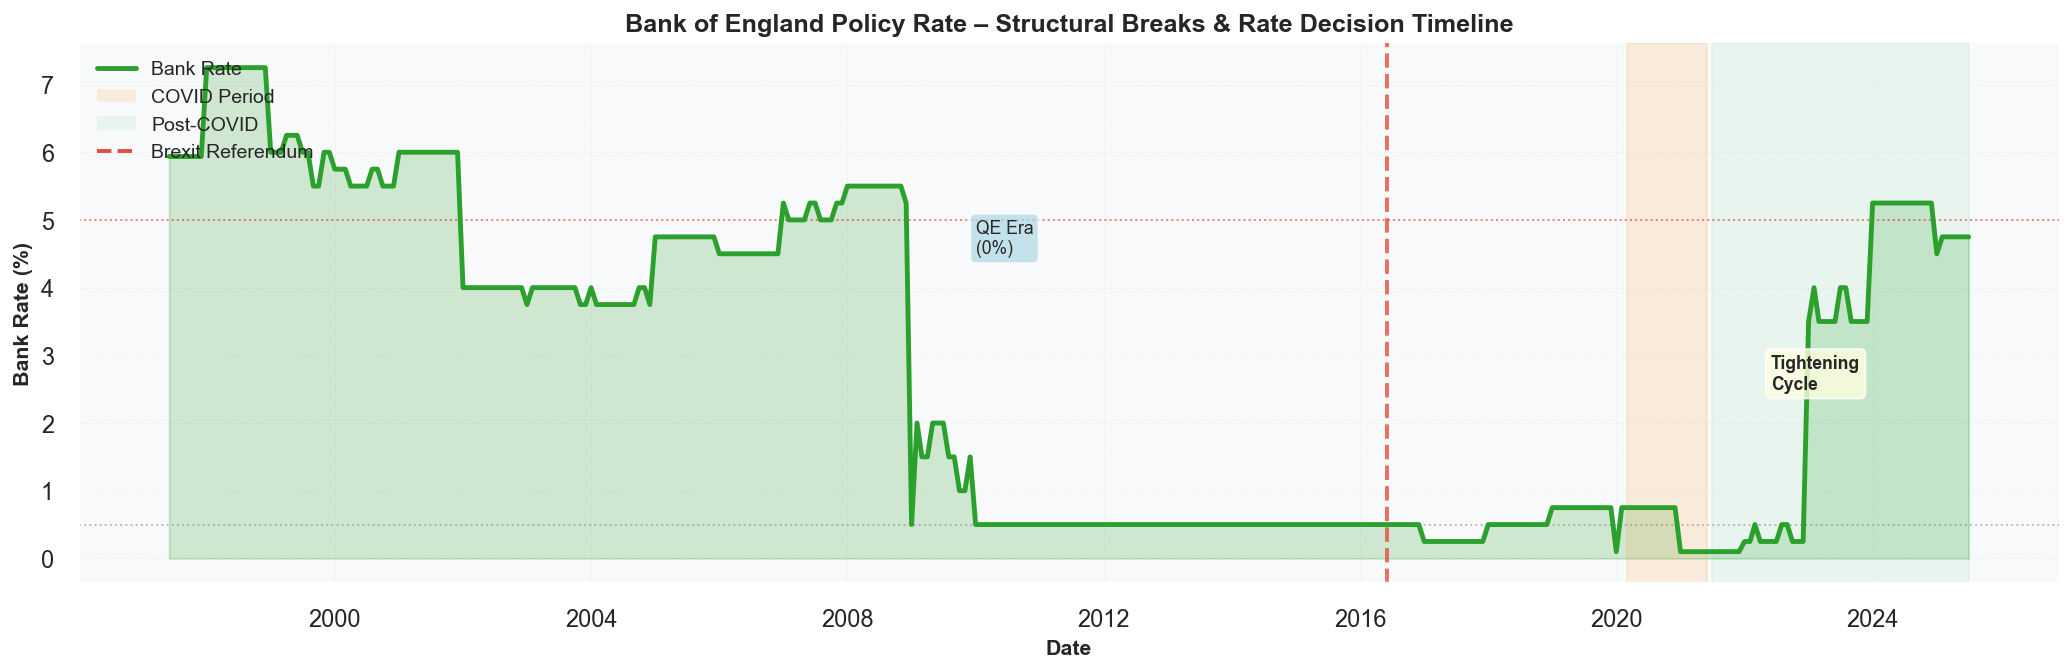

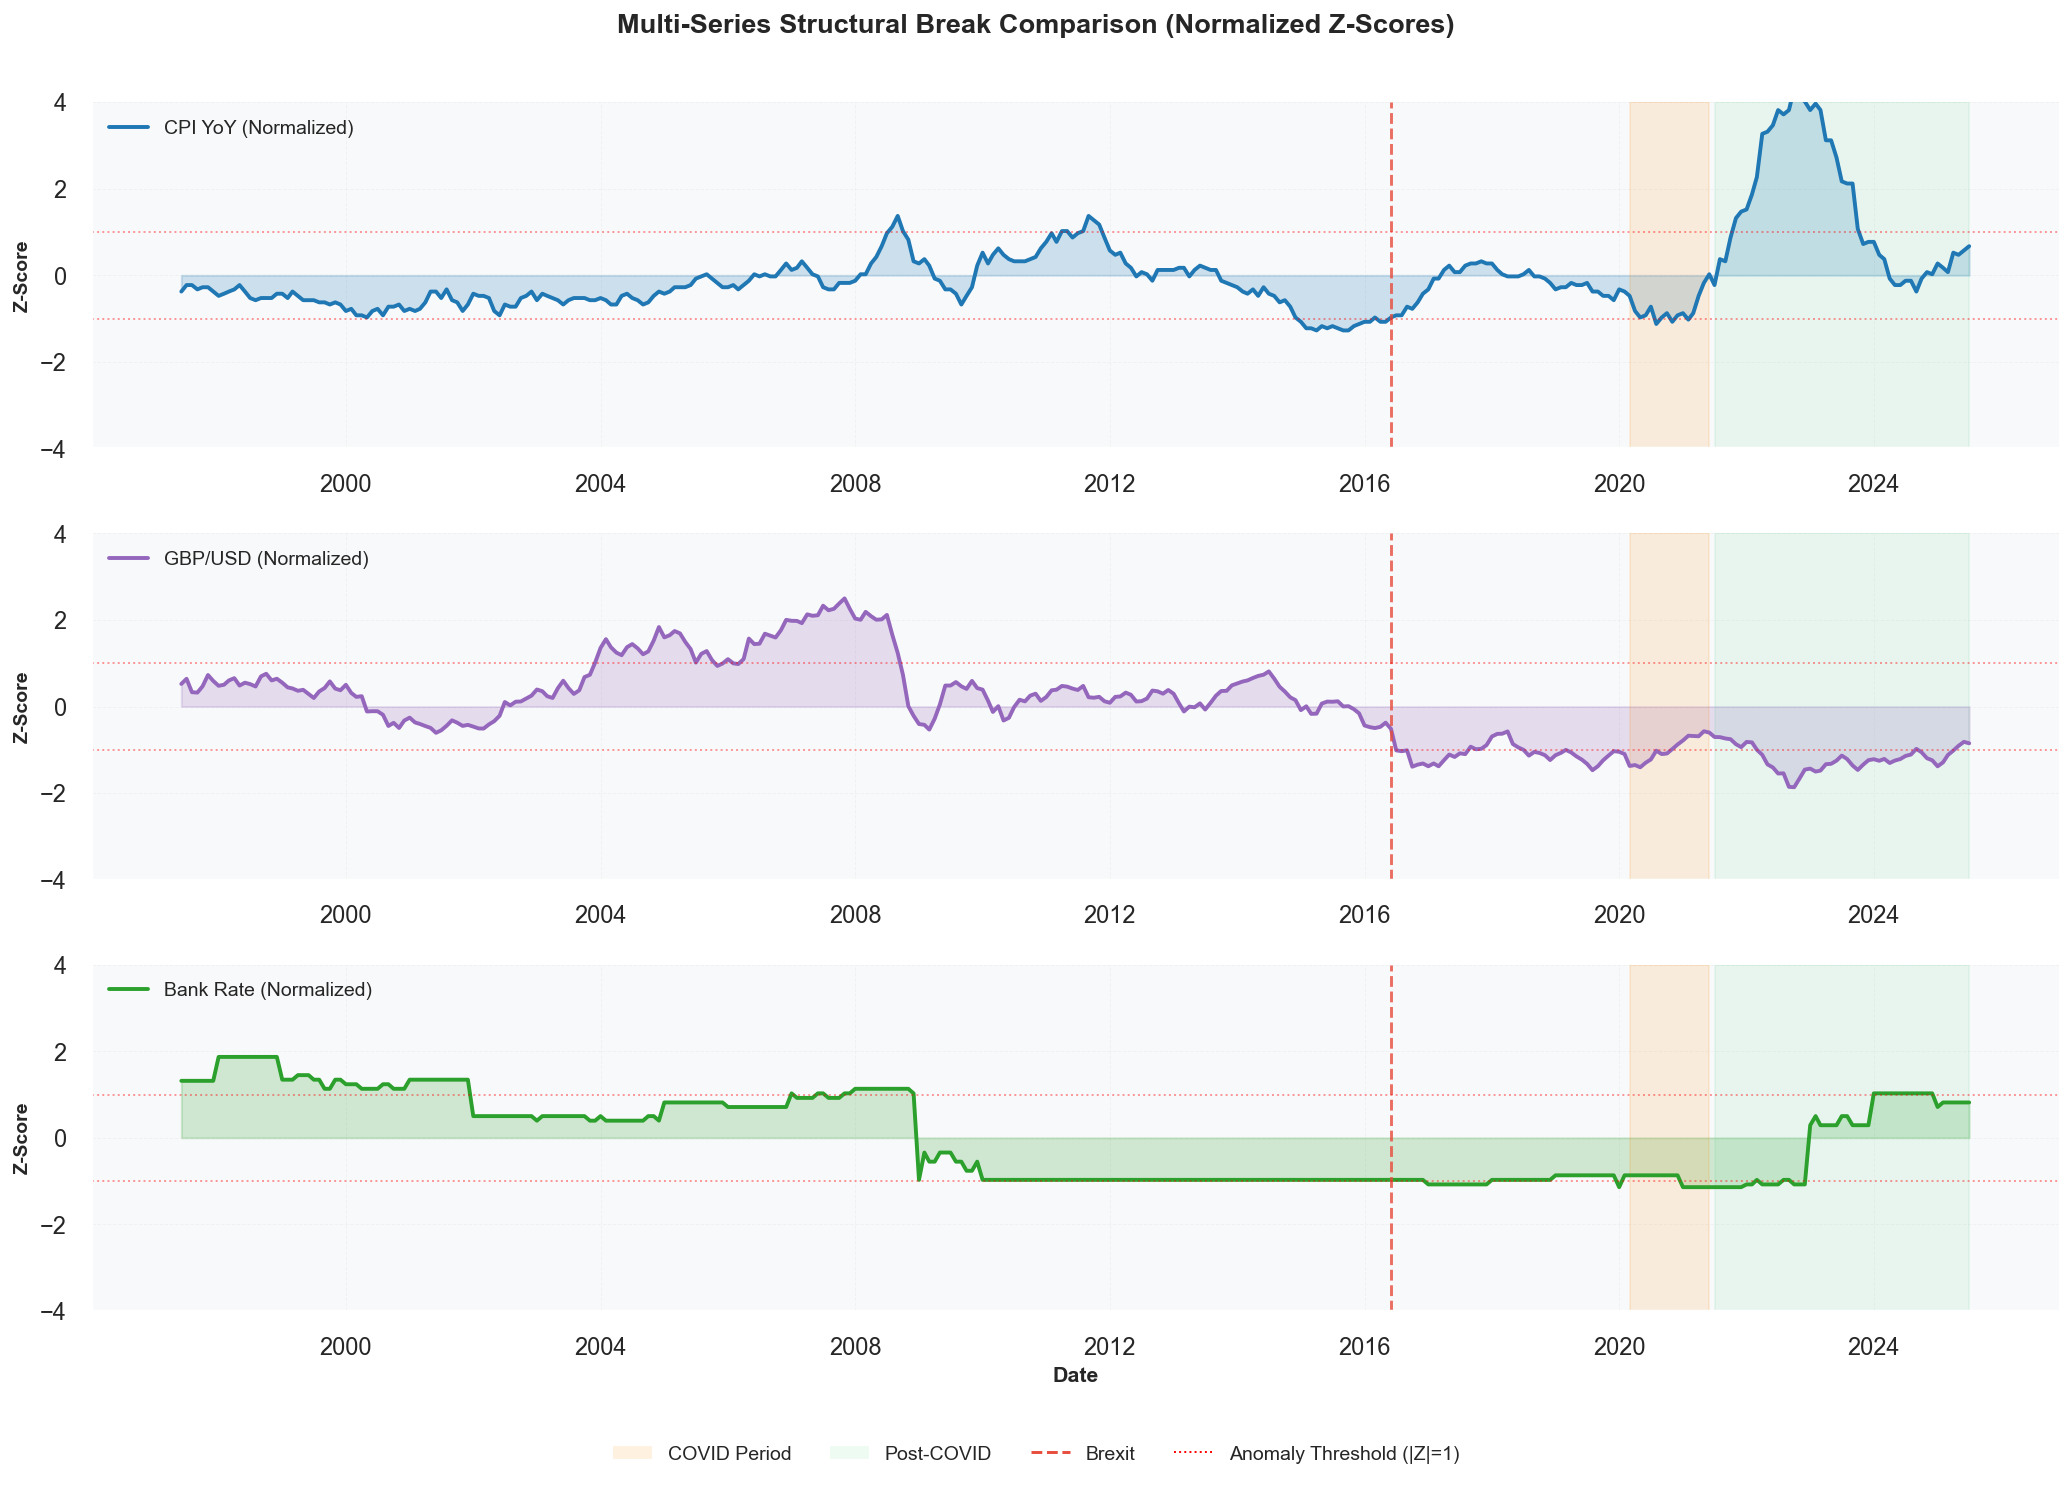


INTERPRETATION:

✅ Structural Breaks Identified:
  1. Brexit (Jun 2016): GBP weakens sharply → imports more expensive
  2. COVID (Mar 2020): Immediate shock to all variables; rate cut to near-zero
  3. Post-COVID (Jul 2021+): Inflation surge; aggressive rate hikes

📊 Key Insights:
  • CPI volatility peaked in 2021-2022 (energy crisis + supply shock)
  • FX shows structural break after Brexit (new 1.2-1.4 range vs pre-Brexit 1.6)
  • Bank Rate jumped from ~0% to 5%+ in fastest tightening cycle in decades

⚠️ Forecasting Implications:
  • Linear models (ARIMA) will fail due to regime changes
  • Use non-linear models (XGBoost, LSTM) or regime-switching models
  • Rolling validation essential (don't use pre-COVID data to forecast post-COVID)
  • Consider separate models for each regime or adaptive learning approaches



In [6]:
# Step 7 — Structural Break Analysis (Enhanced Visualization)

import matplotlib.dates as mdates
from matplotlib.patches import Patch, Rectangle
import matplotlib.patches as mpatches

infl_col = "CPI ANNUAL RATE 00: ALL ITEMS 2015=100"
fx_col   = "Exchange_USD"
bank_col = "Bank Rate"

# ----- Define regime boundaries -----
brexit_date       = pd.to_datetime("2016-06-01")
covid_start       = pd.to_datetime("2020-03-01")
covid_end         = pd.to_datetime("2021-06-01")
post_covid_start  = covid_end + pd.offsets.MonthBegin()

# ========================================================
# Custom function: Detect regime shifts using rolling stats
# ========================================================

def calculate_rolling_zscore(series, window=12):
    """Calculate rolling Z-score to detect anomalies."""
    rolling_mean = series.rolling(window=window).mean()
    rolling_std = series.rolling(window=window).std()
    z_score = (series - rolling_mean) / rolling_std
    return z_score, rolling_mean, rolling_std

z_cpi, rm_cpi, rs_cpi = calculate_rolling_zscore(df[infl_col], window=12)

print("=" * 80)
print("STRUCTURAL BREAK DETECTION – ROLLING STATISTICS")
print("=" * 80)
print(f"\nCPI Series Statistics:")
print(f"  Mean: {df[infl_col].mean():.2f}%")
print(f"  Std Dev: {df[infl_col].std():.2f}%")
print(f"  Min: {df[infl_col].min():.2f}%")
print(f"  Max: {df[infl_col].max():.2f}%")
print(f"\n  High volatility periods (|Z-score| > 1.5):")

high_vol = df[np.abs(z_cpi) > 1.5][["Date", infl_col]]
if len(high_vol) > 0:
    for idx, row in high_vol.iterrows():
        print(f"    {row['Date'].strftime('%Y-%m')}: {row[infl_col]:.2f}% (Z-score: {z_cpi.iloc[idx]:.2f})")
else:
    print("    None detected in standard periods")

print("\n" + "=" * 80)


# ========================================================
# 7.1 CPI with Regime Highlighting & Rolling Mean
# ========================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), dpi=140)

# Top panel: CPI with rolling mean
ax1.plot(df["Date"], df[infl_col], linewidth=1.5, color="#1F77B4", alpha=0.6, label="Actual CPI YoY")
ax1.plot(df["Date"], rm_cpi, linewidth=2.5, color="#FF7F0E", label="12-Month Rolling Mean", zorder=3)

# Highlight regimes
ax1.axvspan(covid_start, covid_end, color="#FF8C00", alpha=0.15)
ax1.axvspan(post_covid_start, df["Date"].max(), color="#2ECC71", alpha=0.10)
ax1.axvline(brexit_date, color="#E74C3C", linestyle="--", linewidth=2, alpha=0.8)

ax1.fill_between(df["Date"], rm_cpi - rs_cpi, rm_cpi + rs_cpi, 
                  color="#FF7F0E", alpha=0.15, label="±1 Std Dev Band")

ax1.set_title("CPI YoY with Rolling Mean & Volatility Bands", fontsize=13, fontweight="bold")
ax1.set_ylabel("Inflation (%)", fontsize=11, fontweight="bold")
ax1.grid(True, alpha=0.3, linestyle="--")
ax1.legend(loc="upper left", fontsize=10)

# Bottom panel: Rolling volatility (standard deviation)
ax2.plot(df["Date"], rs_cpi, linewidth=2.2, color="#D62728", label="12-Month Rolling Volatility")
ax2.fill_between(df["Date"], 0, rs_cpi, color="#D62728", alpha=0.2)

ax2.axvspan(covid_start, covid_end, color="#FF8C00", alpha=0.15)
ax2.axvspan(post_covid_start, df["Date"].max(), color="#2ECC71", alpha=0.10)
ax2.axvline(brexit_date, color="#E74C3C", linestyle="--", linewidth=2, alpha=0.8)

ax2.set_title("CPI Volatility – Highlighting Structural Breaks", fontsize=13, fontweight="bold")
ax2.set_xlabel("Date", fontsize=11, fontweight="bold")
ax2.set_ylabel("Rolling Std Dev (%)", fontsize=11, fontweight="bold")
ax2.grid(True, alpha=0.3, linestyle="--")
ax2.legend(loc="upper left", fontsize=10)

# Custom legend for both
handles = [
    mpatches.Patch(facecolor="#FF8C00", alpha=0.15, label="COVID Period (Mar 2020–Jun 2021)"),
    mpatches.Patch(facecolor="#2ECC71", alpha=0.10, label="Post-COVID (Jul 2021 onwards)"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=2, label="Brexit Referendum (Jun 2016)"),
]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()


# ========================================================
# 7.2 FX (GBP/USD) Structural Breaks with Annotations
# ========================================================

fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[fx_col], linewidth=2.2, color="#9467BD", label="GBP/USD", zorder=3)

# Regime shading
ax.axvspan(covid_start, covid_end, color="#FF8C00", alpha=0.12)
ax.axvspan(post_covid_start, df["Date"].max(), color="#2ECC71", alpha=0.08)
ax.axvline(brexit_date, color="#E74C3C", linestyle="--", linewidth=2, alpha=0.8)

# Annotate Brexit impact
brexit_cpi_val = df[df["Date"] >= brexit_date][fx_col].iloc[0] if len(df[df["Date"] >= brexit_date]) > 0 else None
if brexit_cpi_val:
    ax.annotate("Brexit: GBP\nDepreciation",
                xy=(brexit_date, brexit_cpi_val),
                xytext=(brexit_date + pd.Timedelta(days=180), brexit_cpi_val + 0.15),
                fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="yellow", alpha=0.7),
                arrowprops=dict(arrowstyle="->", color="red", lw=1.5))

# Annotate COVID impact
covid_peak = df[(df["Date"] >= covid_start) & (df["Date"] <= covid_end)][fx_col].min()
covid_date_min = df[(df["Date"] >= covid_start) & (df["Date"] <= covid_end)][fx_col].idxmin()
ax.annotate("COVID:\nSafe-Haven\nFlows",
            xy=(df.loc[covid_date_min, "Date"], covid_peak),
            xytext=(df.loc[covid_date_min, "Date"] + pd.Timedelta(days=180), covid_peak - 0.1),
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="orange", alpha=0.7),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.5))

ax.set_title("GBP/USD Exchange Rate – Structural Breaks with Annotations", fontsize=13, fontweight="bold")
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("GBP per USD", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")

handles = [
    plt.Line2D([], [], color="#9467BD", linewidth=2.2, label="GBP/USD"),
    mpatches.Patch(facecolor="#FF8C00", alpha=0.12, label="COVID"),
    mpatches.Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=2, label="Brexit"),
]
ax.legend(handles=handles, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()


# ========================================================
# 7.3 Bank Rate Structural Breaks with Multi-Regime View
# ========================================================

fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[bank_col], linewidth=2.5, color="#2CA02C", label="Bank Rate", zorder=3)
ax.fill_between(df["Date"], 0, df[bank_col], alpha=0.2, color="#2CA02C")

# Regime shading
ax.axvspan(covid_start, covid_end, color="#FF8C00", alpha=0.12)
ax.axvspan(post_covid_start, df["Date"].max(), color="#2ECC71", alpha=0.08)
ax.axvline(brexit_date, color="#E74C3C", linestyle="--", linewidth=2, alpha=0.8, label="Brexit")

# Mark key rate decisions
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.5)
ax.axhline(5.0, color="red", linestyle=":", linewidth=1, alpha=0.5)

ax.set_title("Bank of England Policy Rate – Structural Breaks & Rate Decision Timeline", 
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("Bank Rate (%)", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")

# Annotate key periods
ax.text(pd.to_datetime("2010-01-01"), 4.5, "QE Era\n(0%)", fontsize=9, 
        bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.7))
ax.text(pd.to_datetime("2022-06-01"), 2.5, "Tightening\nCycle", fontsize=9, fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

handles = [
    plt.Line2D([], [], color="#2CA02C", linewidth=2.5, label="Bank Rate"),
    mpatches.Patch(facecolor="#FF8C00", alpha=0.12, label="COVID Period"),
    mpatches.Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=2, label="Brexit Referendum"),
]
ax.legend(handles=handles, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()


# ========================================================
# 7.4 Multi-Series Structural Break Comparison
# ========================================================

fig, axes = plt.subplots(3, 1, figsize=(15, 10), dpi=140)

# Normalize for comparison (z-score)
z_infl = (df[infl_col] - df[infl_col].mean()) / df[infl_col].std()
z_fx = (df[fx_col] - df[fx_col].mean()) / df[fx_col].std()
z_bank = (df[bank_col] - df[bank_col].mean()) / df[bank_col].std()

for idx, (ax, z_series, color, label) in enumerate([
    (axes[0], z_infl, "#1F77B4", "CPI YoY (Normalized)"),
    (axes[1], z_fx, "#9467BD", "GBP/USD (Normalized)"),
    (axes[2], z_bank, "#2CA02C", "Bank Rate (Normalized)")
]):
    ax.plot(df["Date"], z_series, linewidth=2, color=color, label=label)
    ax.fill_between(df["Date"], 0, z_series, alpha=0.2, color=color)
    
    # Regime shading
    ax.axvspan(covid_start, covid_end, color="#FF8C00", alpha=0.12)
    ax.axvspan(post_covid_start, df["Date"].max(), color="#2ECC71", alpha=0.08)
    ax.axvline(brexit_date, color="#E74C3C", linestyle="--", linewidth=1.5, alpha=0.8)
    
    # Confidence bands
    ax.axhline(1, color="red", linestyle=":", linewidth=1, alpha=0.4)
    ax.axhline(-1, color="red", linestyle=":", linewidth=1, alpha=0.4)
    
    ax.set_ylabel("Z-Score", fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="upper left", fontsize=10)
    ax.set_ylim(-4, 4)

axes[2].set_xlabel("Date", fontsize=11, fontweight="bold")
fig.suptitle("Multi-Series Structural Break Comparison (Normalized Z-Scores)", 
             fontsize=14, fontweight="bold", y=1.00)

handles = [
    mpatches.Patch(facecolor="#FF8C00", alpha=0.12, label="COVID Period"),
    mpatches.Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=1.5, label="Brexit"),
    plt.Line2D([], [], color="red", linestyle=":", linewidth=1, label="Anomaly Threshold (|Z|=1)"),
]
fig.legend(handles=handles, loc="upper center", ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.show()


print("\n" + "=" * 80)
print("INTERPRETATION:")
print("=" * 80)
print("""
✅ Structural Breaks Identified:
  1. Brexit (Jun 2016): GBP weakens sharply → imports more expensive
  2. COVID (Mar 2020): Immediate shock to all variables; rate cut to near-zero
  3. Post-COVID (Jul 2021+): Inflation surge; aggressive rate hikes

📊 Key Insights:
  • CPI volatility peaked in 2021-2022 (energy crisis + supply shock)
  • FX shows structural break after Brexit (new 1.2-1.4 range vs pre-Brexit 1.6)
  • Bank Rate jumped from ~0% to 5%+ in fastest tightening cycle in decades
  
⚠️ Forecasting Implications:
  • Linear models (ARIMA) will fail due to regime changes
  • Use non-linear models (XGBoost, LSTM) or regime-switching models
  • Rolling validation essential (don't use pre-COVID data to forecast post-COVID)
  • Consider separate models for each regime or adaptive learning approaches
""")
print("=" * 80)

---

## 8. Conclusions and Next Steps

### 8.1 Summary of EDA Findings

This exploratory analysis has revealed several critical insights for UK inflation forecasting:

1. **Structural Instability:** Brexit (2016), COVID-19 (2020-2021), and the energy crisis (2022-2023) represent distinct regime changes in inflation dynamics, invalidating stationary modelling assumptions.

2. **Multi-Variate Dependencies:** No single predictor dominates inflation behaviour. Energy prices exhibit the strongest relationship (r ≈ 0.45), but exchange rates, monetary policy, labour market conditions, and economic activity all contribute meaningfully.

3. **Non-Linear Relationships:** U-shaped functional forms in scatter plots indicate threshold effects and non-linearities that linear models cannot capture adequately.

4. **Volatility Clustering:** CPI volatility increased fourfold during 2021-2023, creating unprecedented forecasting uncertainty and highlighting the need for adaptive or regime-aware modelling approaches.

5. **Leading Indicators:** Energy prices and exchange rates exhibit 1-6 month lead times, providing valuable signals for nowcasting and short-term forecasting applications.

### 8.2 Implications for Model Development

Based on these findings, the forecasting phase will implement:

- **Non-linear architectures:** XGBoost and LSTM models to capture complex variable interactions
- **Feature engineering:** Lagged variables (t-1, t-3, t-6) for energy prices and exchange rates
- **Temporal validation:** Rolling window cross-validation to account for regime changes
- **Uncertainty quantification:** Probabilistic forecasts rather than point estimates
- **Explainability mechanisms:** SHAP values and attention weights to interpret model decisions

### 8.3 Limitations and Future Work

**Data Limitations:**
- Monthly frequency limits short-term nowcasting capabilities
- Missing variables (e.g., inflation expectations, global supply chain indices) may improve accuracy
- Recent regime (2022-2023) has limited historical observations for training

**Methodological Extensions:**
- Regime-switching models explicitly modelling structural breaks
- Incorporation of text data (central bank communications, news sentiment)
- Multi-horizon forecasting (1, 3, 6, 12 months ahead)

---

**End of Exploratory Data Analysis**

The next notebook will focus on feature engineering, model training, hyperparameter optimisation, and explainability analysis.